# SecMutBench Results Summary
**Dataset v2.8.0** | 339 samples | 30 CWEs | 1869 mutants

In [1]:
%matplotlib inline

import json
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib.patches import Patch

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (12, 6)

MODEL_COLORS = {
    'qwen3-30b': '#1f77b4',
    'deepseek-v2': '#ff7f0e',
    'qwen2.5-14b': '#2ca02c',
    'gpt-5.2': '#d62728',
    'gpt-oss-120b': '#9467bd',
    'gpt-5-mini': '#8c564b',
    'glm-5': '#e377c2',
    'kimi-k2.5': '#7f7f7f',
    'reference': '#17becf',
}

RESULT_FILES = {
    'qwen3-30b': 'results/qwen3-coder_30b/baseline_results_20260313_081511.json',
    'deepseek-v2': 'results/deepseek-coder-v2_latest/baseline_results_20260313_192250.json',
    'qwen2.5-14b': 'results/qwen2.5-coder_14b-instruct/baseline_results_20260314_044805.json',
    'gpt-5.2': 'results/gpt-5.2-2025-12-11/baseline_results_20260314_210150.json',
    'gpt-oss-120b': 'results/gpt-oss-120b/baseline_results_20260314_183442.json',
    'gpt-5-mini': 'results/gpt-5-mini-2025-08-07/baseline_results_20260314_230056.json',
    'glm-5': 'results/glm-5_cloud_ollama/baseline_results_20260316_001816.json',
    'kimi-k2.5': 'results/kimi-k2.5_cloud_ollama/baseline_results_20260316_195930.json',
}

DIFFICULTY_COLORS = {'easy': '#2ca02c', 'medium': '#ff7f0e', 'hard': '#d62728'}
DIFFICULTY_ORDER = ['easy', 'medium', 'hard']

print('Setup complete.')

Setup complete.


In [2]:
# Load dataset2.json
with open('data/dataset2.json', 'r') as f:
    dataset = json.load(f)

# Build dataset_df
dataset_rows = []
mutant_rows = []
for sample in dataset['samples']:
    sid = sample['id']
    cwe = sample['cwe']
    cwe_name = sample.get('cwe_name', '')
    difficulty = sample.get('difficulty', 'unknown')
    source_type = sample.get('source_type', 'original')
    mutants = sample.get('mutants', [])
    operators = sample.get('mutation_operators', [])
    dataset_rows.append({
        'id': sid,
        'cwe': cwe,
        'cwe_name': cwe_name,
        'difficulty': difficulty,
        'source_type': source_type,
        'num_mutants': len(mutants),
        'num_operators': len(operators),
    })
    for m in mutants:
        mutant_rows.append({
            'sample_id': sid,
            'cwe': cwe,
            'operator': m.get('operator', 'unknown'),
            'mutant_category': m.get('mutant_category', 'unknown'),
            'variant_type': m.get('variant_type', 'unknown'),
        })

dataset_df = pd.DataFrame(dataset_rows)
mutants_df = pd.DataFrame(mutant_rows)

print(f'Dataset: {len(dataset_df)} samples, {dataset_df["cwe"].nunique()} CWEs, {len(mutants_df)} mutants')
print(f'Difficulty: {dict(dataset_df["difficulty"].value_counts())}')
print(f'Source type: {dict(dataset_df["source_type"].value_counts())}')

Dataset: 339 samples, 30 CWEs, 1869 mutants
Difficulty: {'easy': np.int64(136), 'hard': np.int64(102), 'medium': np.int64(101)}
Source type: {'variation': np.int64(258), 'original': np.int64(81)}


## Dataset Composition

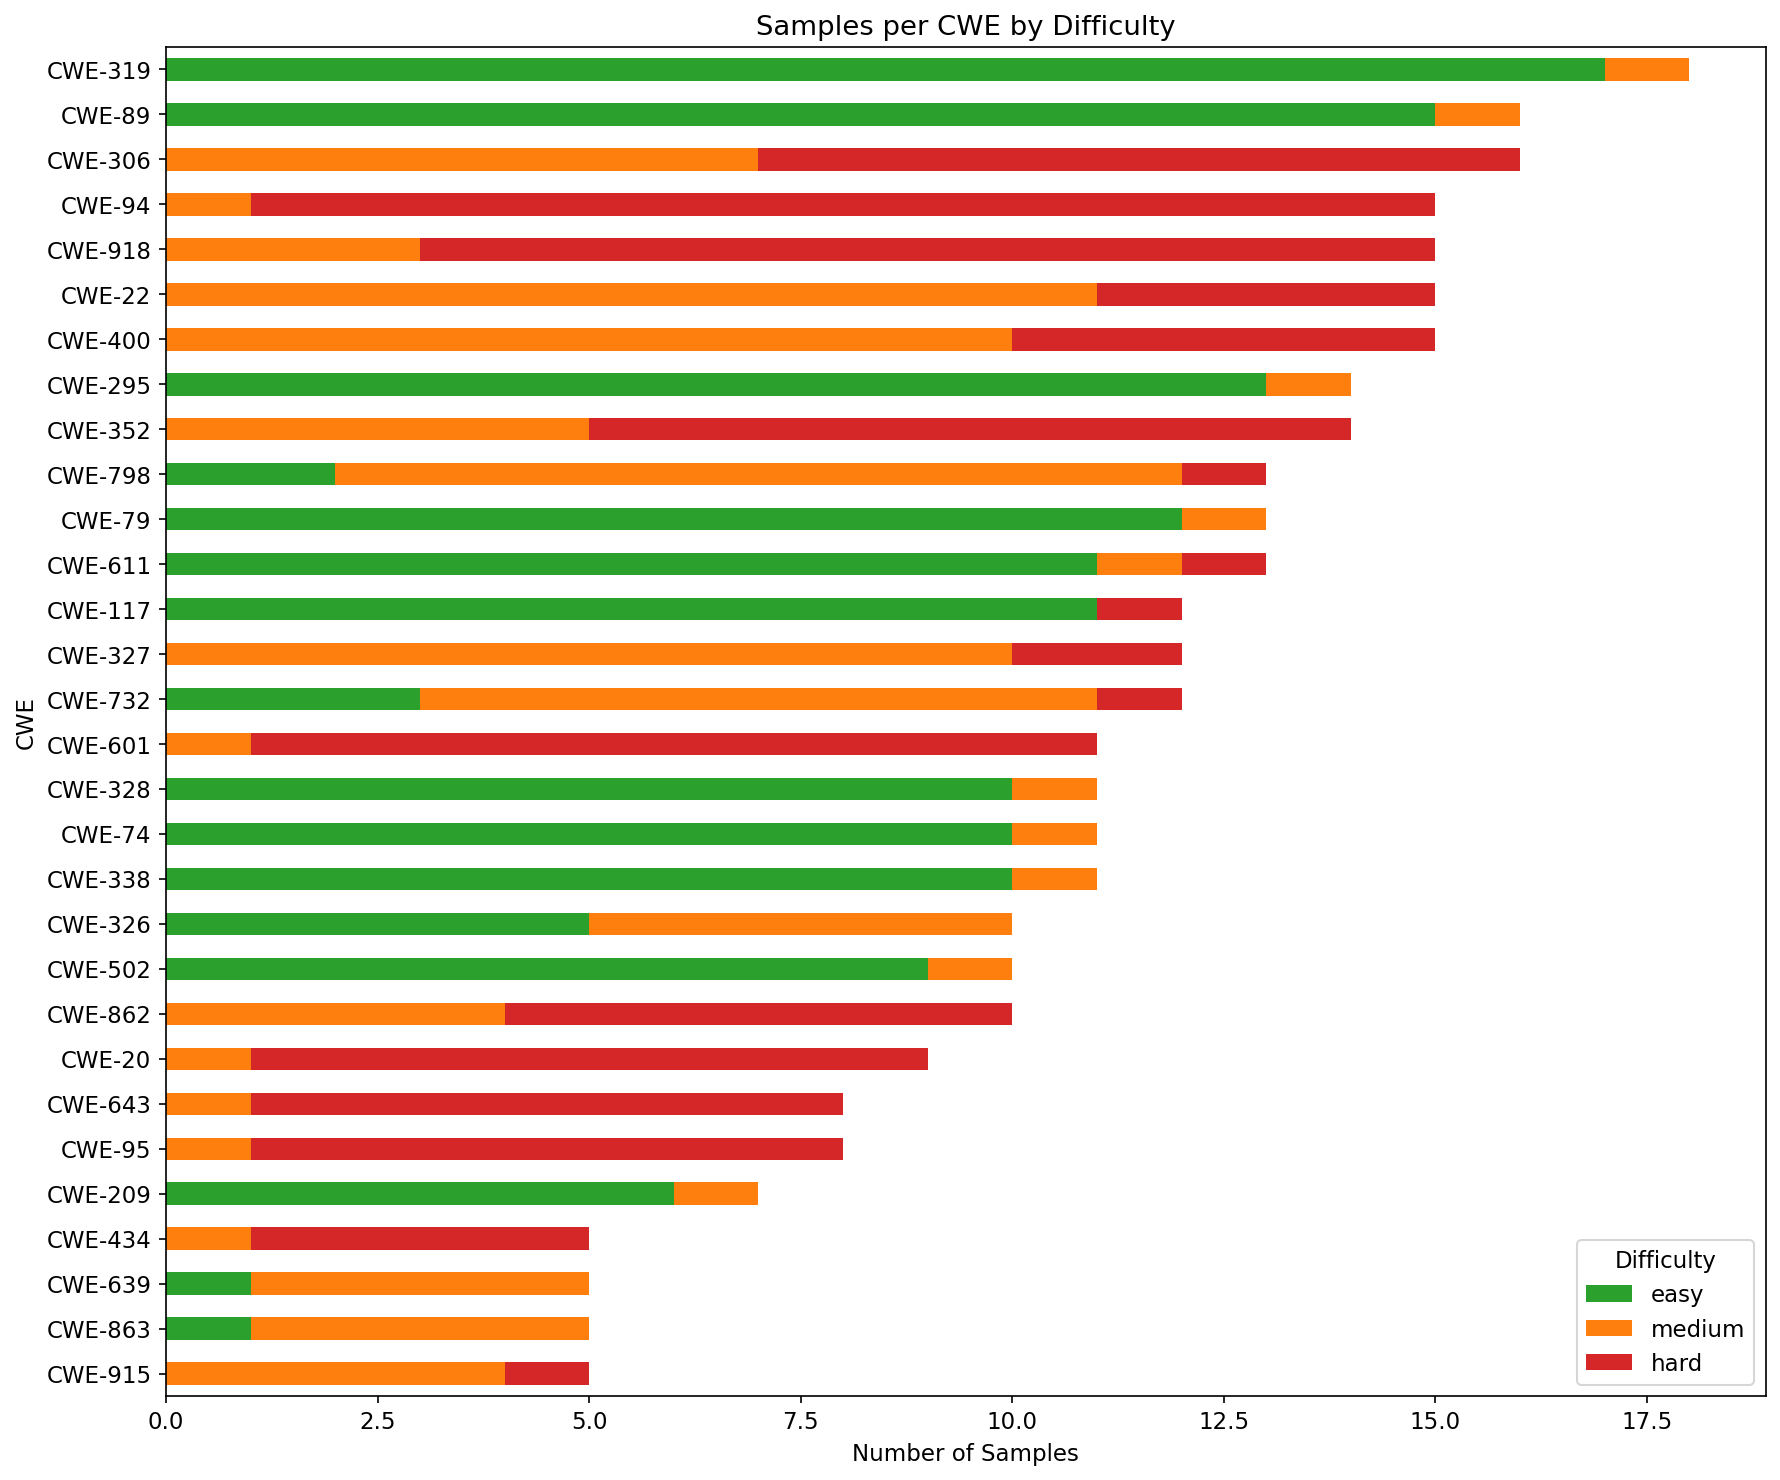

In [3]:
# CWE Distribution - horizontal bar chart stacked by difficulty
cwe_diff = dataset_df.groupby(['cwe', 'difficulty']).size().unstack(fill_value=0)
cwe_diff = cwe_diff.reindex(columns=DIFFICULTY_ORDER, fill_value=0)
cwe_diff['total'] = cwe_diff.sum(axis=1)
cwe_diff = cwe_diff.sort_values('total', ascending=True)
cwe_diff = cwe_diff.drop(columns='total')

fig, ax = plt.subplots(figsize=(12, 10))
cwe_diff.plot.barh(stacked=True, color=[DIFFICULTY_COLORS[d] for d in DIFFICULTY_ORDER], ax=ax)
ax.set_xlabel('Number of Samples')
ax.set_ylabel('CWE')
ax.set_title('Samples per CWE by Difficulty')
ax.legend(title='Difficulty')
plt.tight_layout()
plt.show()

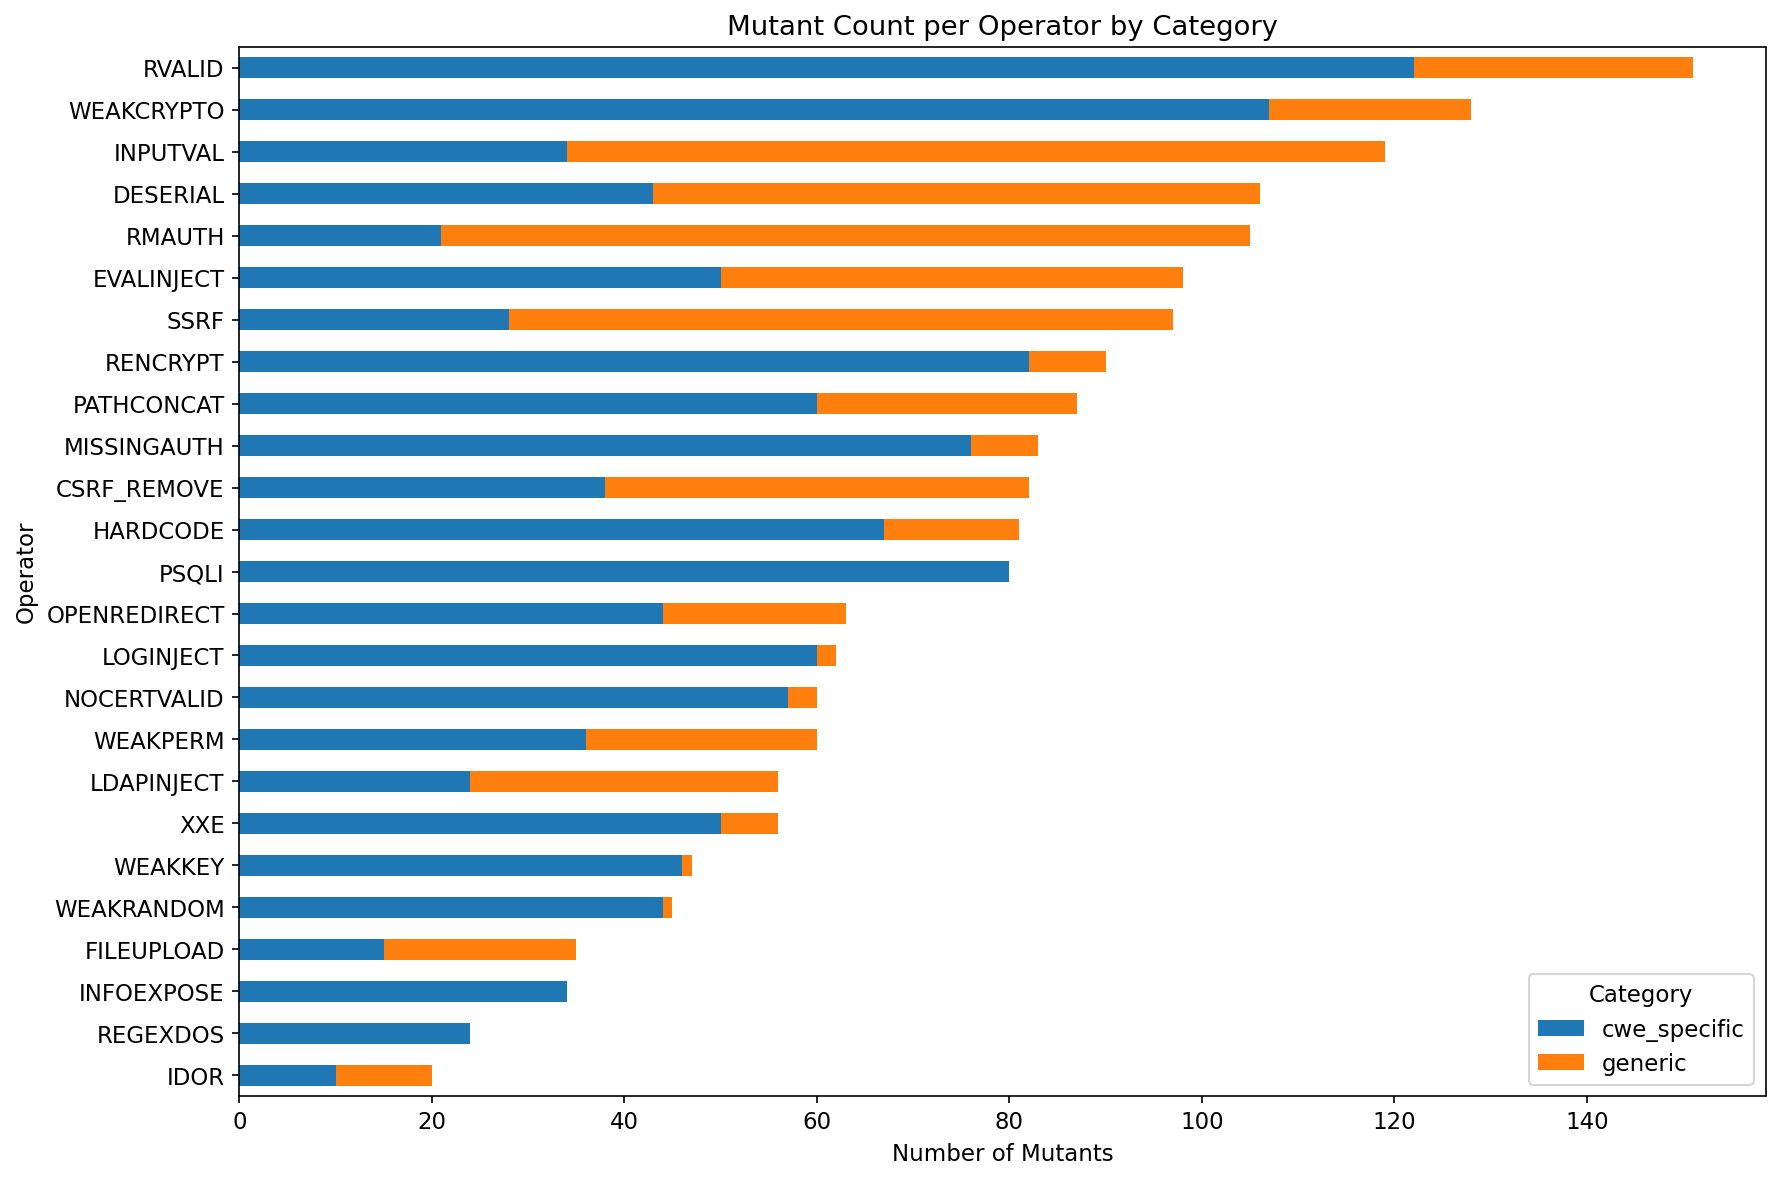

In [4]:
# Mutation Operator Frequency - stacked by mutant_category
op_cat = mutants_df.groupby(['operator', 'mutant_category']).size().unstack(fill_value=0)
cat_cols = [c for c in ['cwe_specific', 'generic'] if c in op_cat.columns]
op_cat = op_cat.reindex(columns=cat_cols, fill_value=0)
op_cat['total'] = op_cat.sum(axis=1)
op_cat = op_cat.sort_values('total', ascending=True)
op_cat = op_cat.drop(columns='total')

cat_colors = {'cwe_specific': '#1f77b4', 'generic': '#ff7f0e'}

fig, ax = plt.subplots(figsize=(12, 8))
op_cat.plot.barh(stacked=True, color=[cat_colors.get(c, '#999999') for c in op_cat.columns], ax=ax)
ax.set_xlabel('Number of Mutants')
ax.set_ylabel('Operator')
ax.set_title('Mutant Count per Operator by Category')
ax.legend(title='Category')
plt.tight_layout()
plt.show()

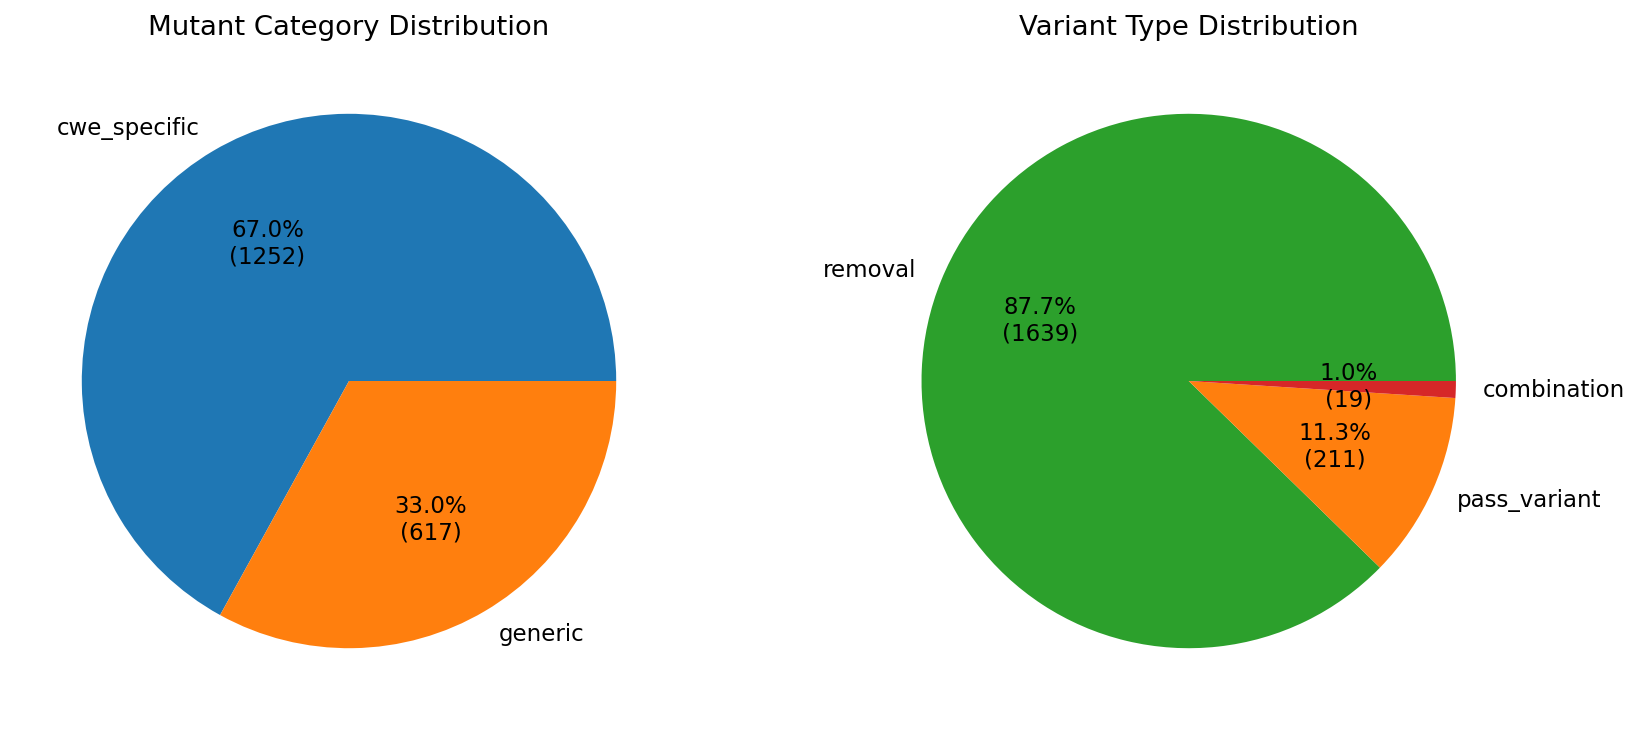

In [5]:
# Mutant Categories & Variant Types - 2 pie charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cat_counts = mutants_df['mutant_category'].value_counts()
ax1.pie(cat_counts, labels=cat_counts.index, autopct=lambda p: f'{p:.1f}%\n({int(p*len(mutants_df)/100)})',
        colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(cat_counts)])
ax1.set_title('Mutant Category Distribution')

var_counts = mutants_df['variant_type'].value_counts()
ax2.pie(var_counts, labels=var_counts.index, autopct=lambda p: f'{p:.1f}%\n({int(p*len(mutants_df)/100)})',
        colors=['#2ca02c', '#ff7f0e', '#d62728', '#9467bd', '#8c564b'][:len(var_counts)])
ax2.set_title('Variant Type Distribution')

plt.tight_layout()
plt.show()

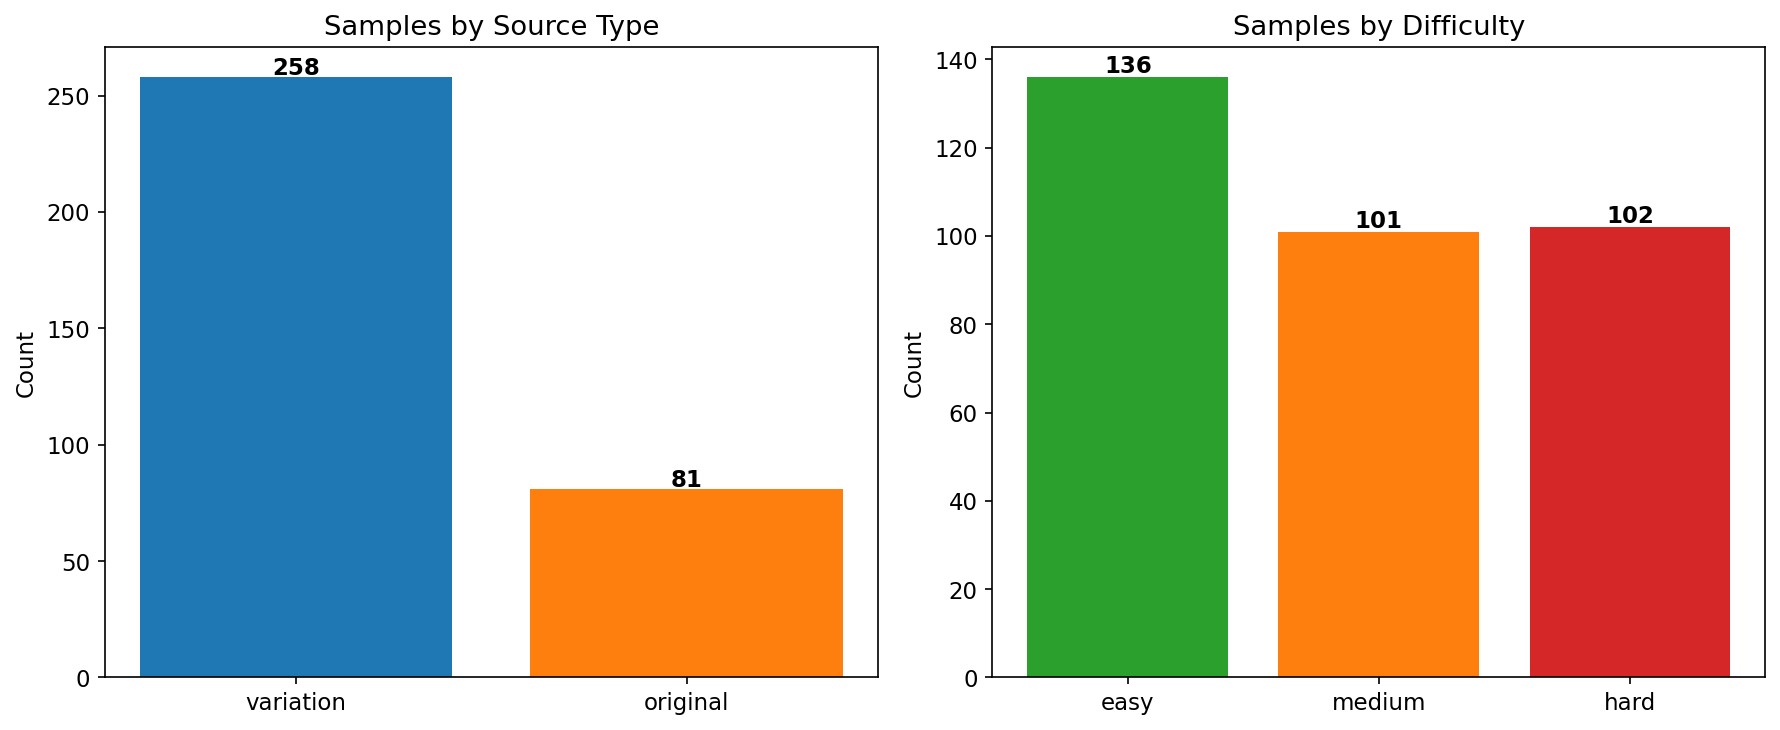

In [6]:
# Source Type & Difficulty
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

src_counts = dataset_df['source_type'].value_counts()
ax1.bar(src_counts.index, src_counts.values, color=['#1f77b4', '#ff7f0e'][:len(src_counts)])
ax1.set_title('Samples by Source Type')
ax1.set_ylabel('Count')
for i, v in enumerate(src_counts.values):
    ax1.text(i, v + 1, str(v), ha='center', fontweight='bold')

diff_counts = dataset_df['difficulty'].value_counts().reindex(DIFFICULTY_ORDER)
ax2.bar(diff_counts.index, diff_counts.values, color=[DIFFICULTY_COLORS[d] for d in DIFFICULTY_ORDER])
ax2.set_title('Samples by Difficulty')
ax2.set_ylabel('Count')
for i, v in enumerate(diff_counts.values):
    ax2.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

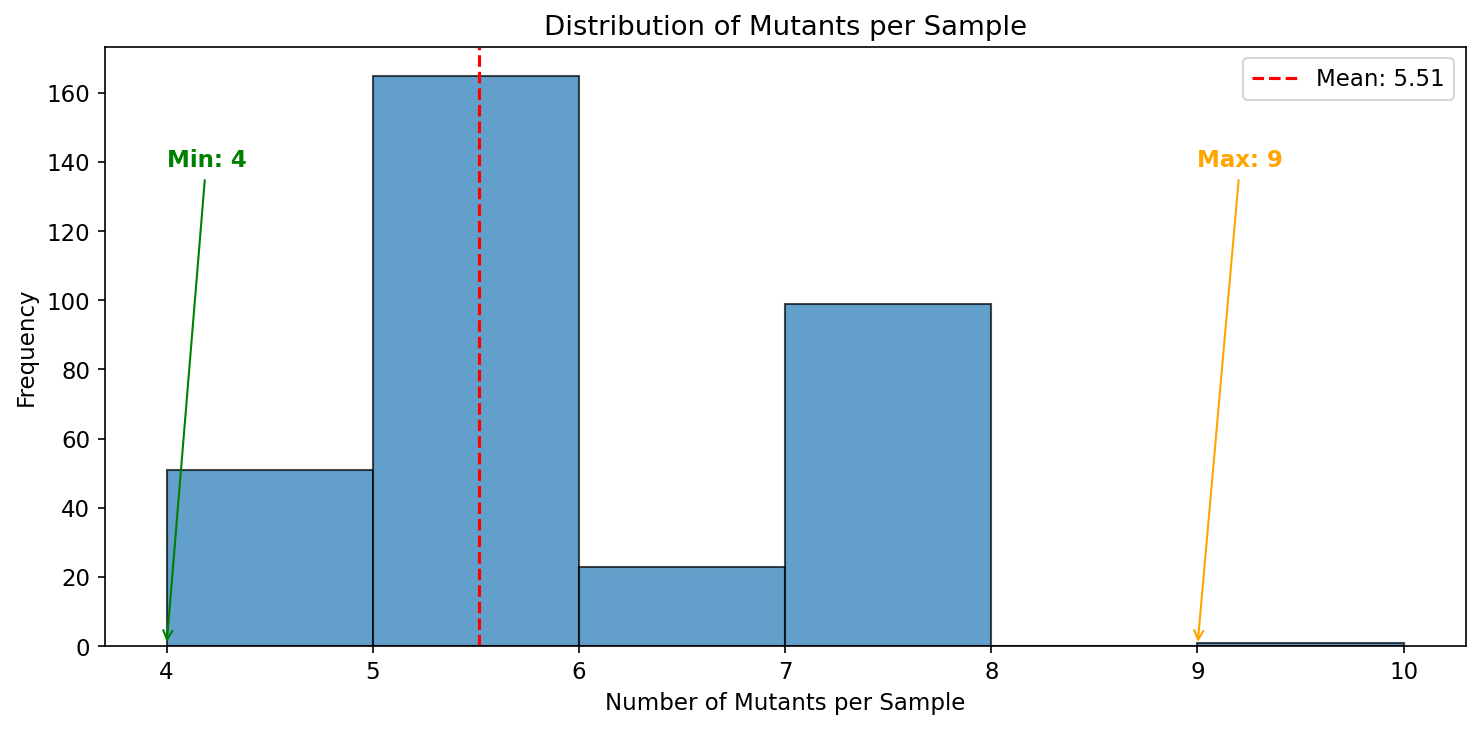

In [7]:
# Mutants per Sample histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(dataset_df['num_mutants'], bins=range(dataset_df['num_mutants'].min(), dataset_df['num_mutants'].max() + 2),
        edgecolor='black', alpha=0.7, color='#1f77b4')
mean_val = dataset_df['num_mutants'].mean()
min_val = dataset_df['num_mutants'].min()
max_val = dataset_df['num_mutants'].max()
ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax.set_xlabel('Number of Mutants per Sample')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Mutants per Sample')
ax.legend()
ax.annotate(f'Min: {min_val}', xy=(min_val, 0), xytext=(min_val, ax.get_ylim()[1]*0.8),
            arrowprops=dict(arrowstyle='->', color='green'), color='green', fontweight='bold')
ax.annotate(f'Max: {max_val}', xy=(max_val, 0), xytext=(max_val, ax.get_ylim()[1]*0.8),
            arrowprops=dict(arrowstyle='->', color='orange'), color='orange', fontweight='bold')
plt.tight_layout()
plt.show()

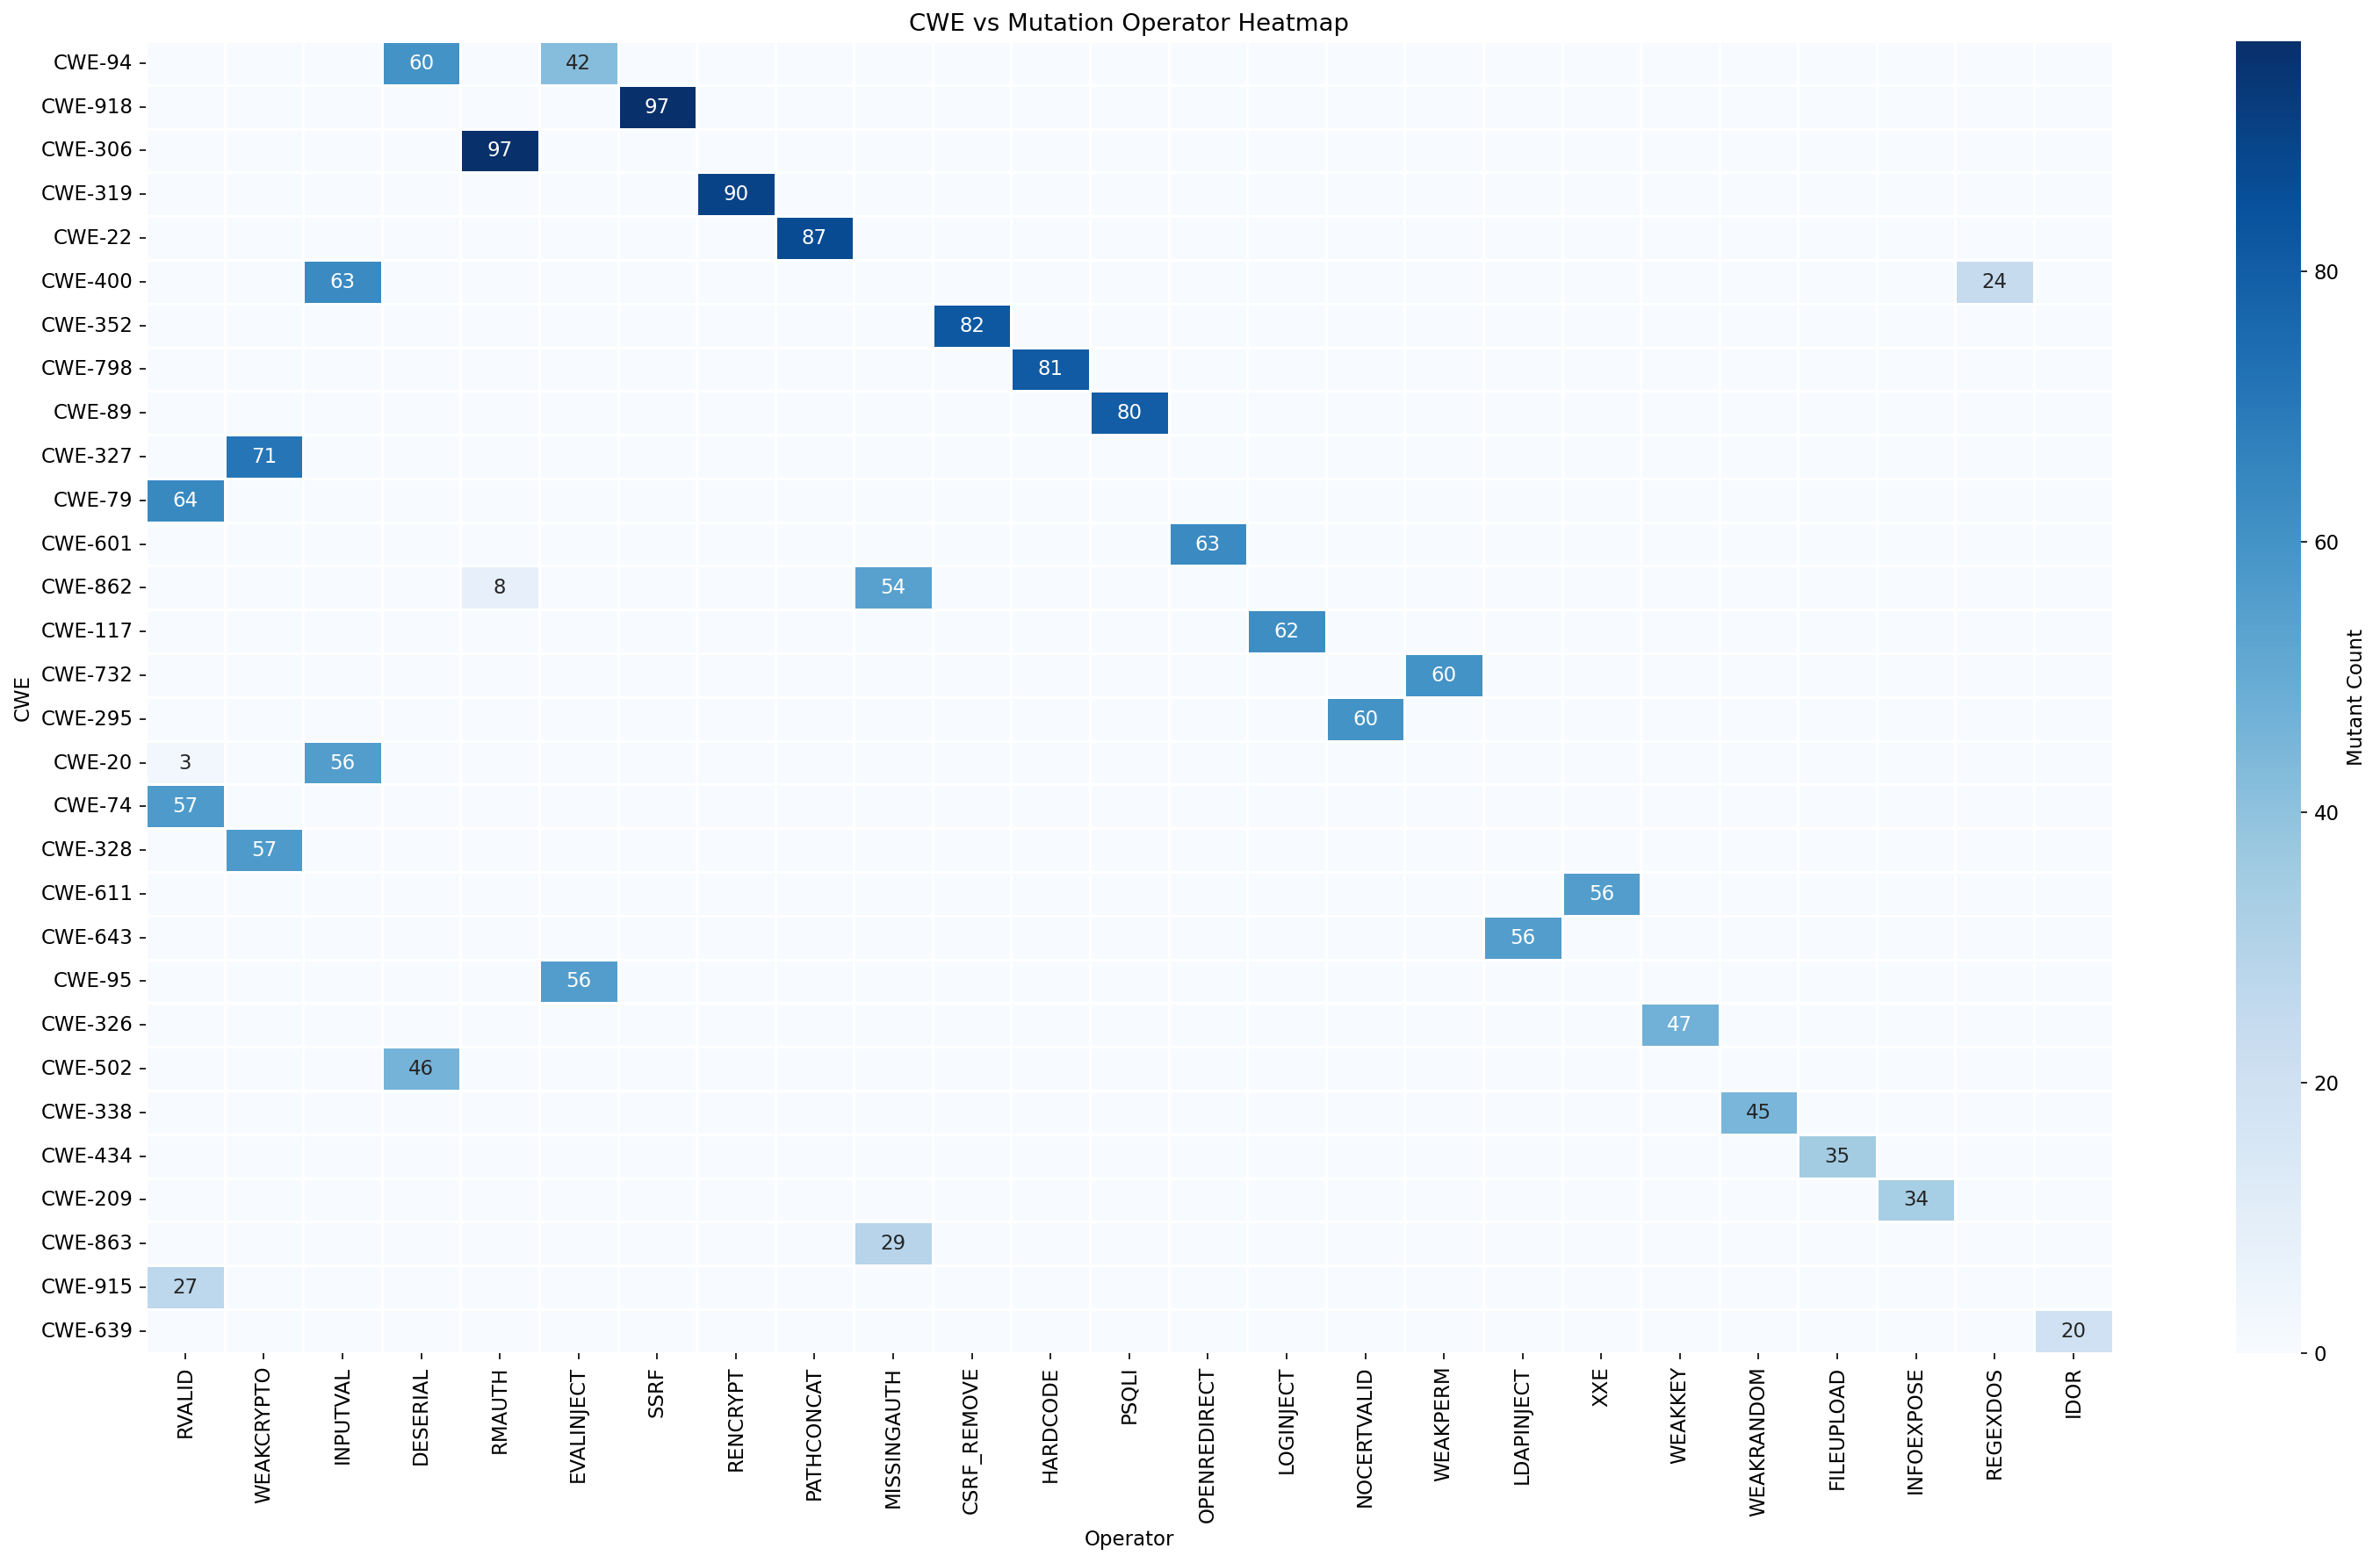

In [8]:
# CWE x Operator Heatmap
cross = pd.crosstab(mutants_df['cwe'], mutants_df['operator'])
# Sort CWEs by total mutants, operators by total mutants
cross = cross.loc[cross.sum(axis=1).sort_values(ascending=False).index]
cross = cross[cross.sum(axis=0).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(20, 12))
# Annotate only non-zero values
annot = cross.copy().astype(str)
annot[cross == 0] = ''
sns.heatmap(cross, cmap='Blues', annot=annot, fmt='', ax=ax, linewidths=0.5, cbar_kws={'label': 'Mutant Count'})
ax.set_title('CWE vs Mutation Operator Heatmap')
ax.set_xlabel('Operator')
ax.set_ylabel('CWE')
plt.tight_layout()
plt.show()

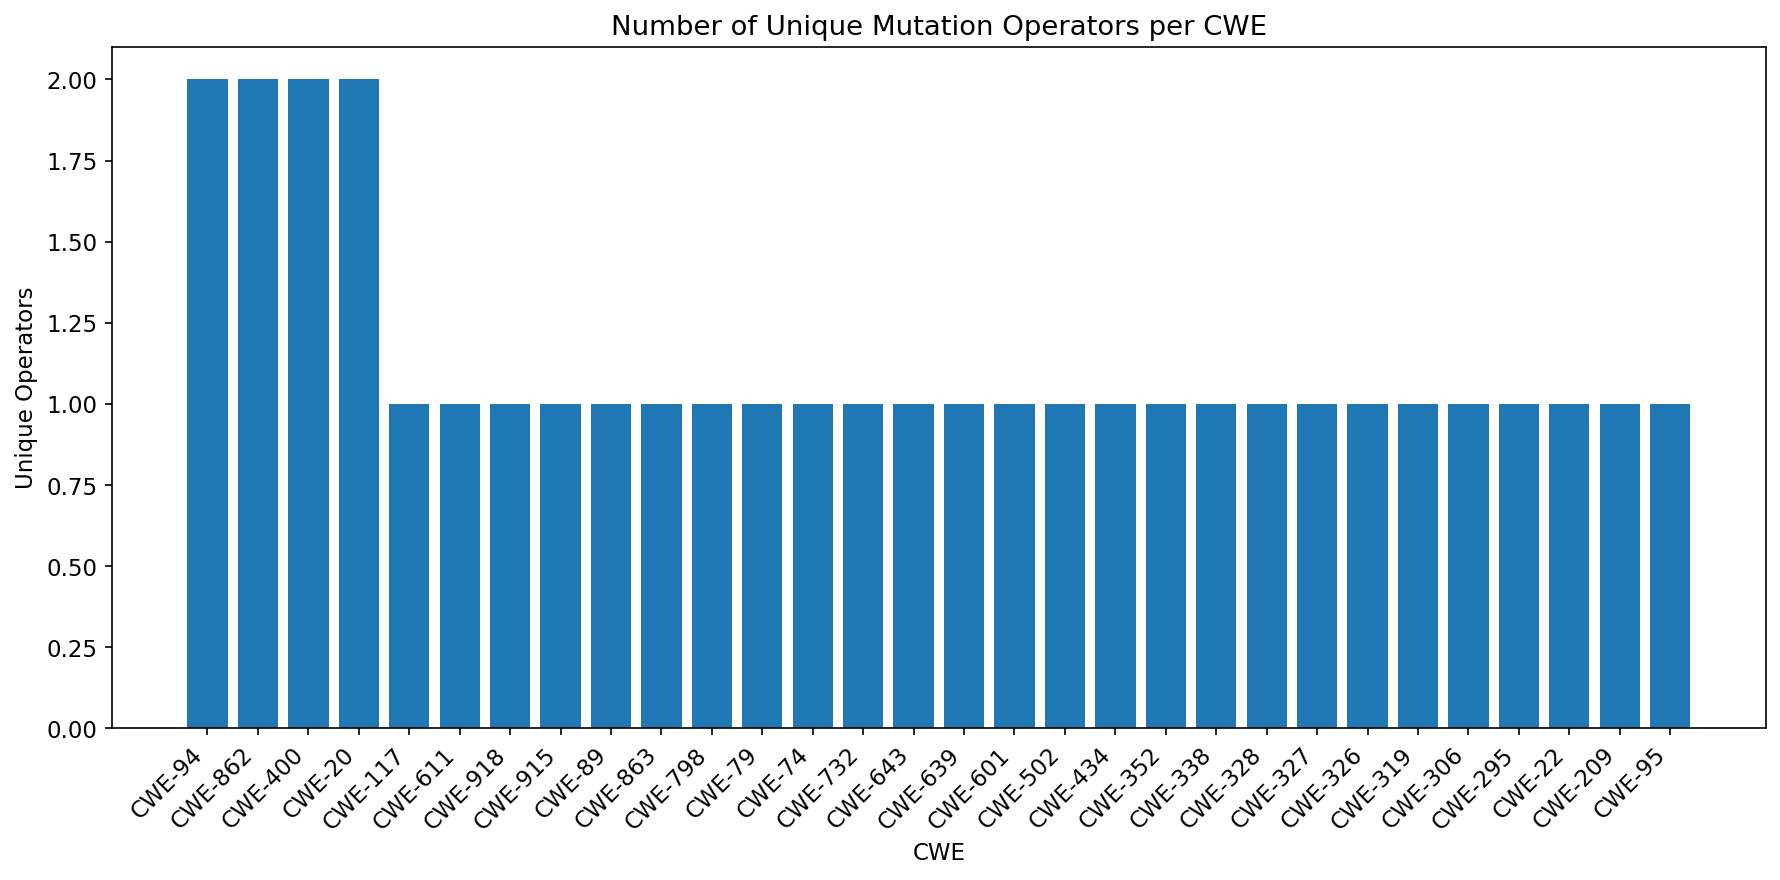

In [9]:
# Operators per CWE
ops_per_cwe = mutants_df.groupby('cwe')['operator'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(ops_per_cwe)), ops_per_cwe.values, color='#1f77b4')
ax.set_xticks(range(len(ops_per_cwe)))
ax.set_xticklabels(ops_per_cwe.index, rotation=45, ha='right')
ax.set_xlabel('CWE')
ax.set_ylabel('Unique Operators')
ax.set_title('Number of Unique Mutation Operators per CWE')
plt.tight_layout()
plt.show()

# Part 2: Model Evaluation Results

In [10]:
# Load all model results
models_rows = []
samples_rows = []

for model_name, fpath in RESULT_FILES.items():
    if not os.path.exists(fpath):
        print(f'WARNING: {fpath} not found, skipping {model_name}')
        continue
    with open(fpath, 'r') as f:
        data = json.load(f)
    
    # Use only the [full] prompt variant (first result)
    all_results = data.get('results', [data] if 'model_name' in data else [])
    for result in all_results[:1]:
        models_rows.append({
            'model': model_name,
            'samples': result.get('samples_evaluated', 0),
            'avg_mutation_score': result.get('avg_mutation_score', 0),
            'avg_security_mutation_score': result.get('avg_security_mutation_score', 0),
            'avg_incidental_score': result.get('avg_incidental_score', 0),
            'avg_crash_score': result.get('avg_crash_score', 0),
            'avg_security_precision': result.get('avg_security_precision', 0),
            'secure_pass_rate': result.get('secure_pass_rate', 0),
        })
        for det in result.get('detailed_results', []):
            metrics = det.get('metrics', {})
            samples_rows.append({
                'model': model_name,
                'sample_id': det.get('sample_id', ''),
                'cwe': det.get('cwe', ''),
                'difficulty': det.get('difficulty', ''),
                'source_type': det.get('source_type', ''),
                'mutation_score': metrics.get('mutation_score', 0),
                'mutants_killed': metrics.get('mutants_killed', 0),
                'mutants_total': metrics.get('mutants_total', 0),
                'valid_tests': metrics.get('valid_tests', 0),
                'secure_passes': metrics.get('secure_passes', 0),
                'tests_count': metrics.get('tests_count', 0),
            })

# Load reference tests
ref_path = 'results/reference_tests_v28.json'
if os.path.exists(ref_path):
    with open(ref_path, 'r') as f:
        ref_data = json.load(f)
    ref_summary = ref_data.get('summary', {})
    kb = ref_summary.get('kill_breakdown', {})
    models_rows.append({
        'model': 'reference',
        'samples': ref_summary.get('samples', ref_summary.get('total_samples', 339)),
        'avg_mutation_score': ref_summary.get('avg_mutation_score', 0),
        'avg_security_mutation_score': kb.get('security_mutation_score', 0),
        'avg_incidental_score': kb.get('avg_incidental_score', 0),
        'avg_crash_score': kb.get('avg_crash_score', 0),
        'avg_security_precision': ref_summary.get('avg_security_precision', 0),
        'secure_pass_rate': ref_summary.get('secure_pass_rate', 0),
    })

models_df = pd.DataFrame(models_rows)
samples_df = pd.DataFrame(samples_rows)

print(f'Loaded {len(models_df)} model results, {len(samples_df)} sample-level results')
print(f'Models: {models_df["model"].tolist()}')

Loaded 9 model results, 2712 sample-level results
Models: ['qwen3-30b', 'deepseek-v2', 'qwen2.5-14b', 'gpt-5.2', 'gpt-oss-120b', 'gpt-5-mini', 'glm-5', 'kimi-k2.5', 'reference']


In [11]:
# Load judge scores
judge_rows = []

for model_name, fpath in RESULT_FILES.items():
    base = fpath.replace('.json', '')
    
    # Security judge
    sec_path = base + '_judged_security.json'
    sec_data = {}
    if os.path.exists(sec_path):
        try:
            with open(sec_path, 'r') as f:
                sec_raw = json.load(f)
            for result in sec_raw.get('results', [sec_raw] if 'detailed_results' in sec_raw else []):
                for det in result.get('detailed_results', []):
                    js = det.get('judge_security', {})
                    if js:
                        sec_data[det.get('sample_id', '')] = {
                            'sec_judge_score': js.get('score', np.nan),
                            'cwe_addressed': js.get('cwe_addressed', None),
                        }
        except Exception as e:
            print(f'Error loading security judge for {model_name}: {e}')
    
    # Quality judge
    qual_path = base + '_judged_quality.json'
    qual_data = {}
    if os.path.exists(qual_path):
        try:
            with open(qual_path, 'r') as f:
                qual_raw = json.load(f)
            for result in qual_raw.get('results', [qual_raw] if 'detailed_results' in qual_raw else []):
                for det in result.get('detailed_results', []):
                    jq = det.get('judge_quality', {})
                    if jq:
                        qual_data[det.get('sample_id', '')] = {
                            'qual_judge_score': jq.get('score', np.nan),
                        }
        except Exception as e:
            print(f'Error loading quality judge for {model_name}: {e}')
    
    # OpenAI judge
    oai_path = base + '_openai_judged.json'
    oai_data = {}
    if os.path.exists(oai_path):
        try:
            with open(oai_path, 'r') as f:
                oai_raw = json.load(f)
            for result in oai_raw.get('results', [oai_raw] if 'detailed_results' in oai_raw else []):
                for det in result.get('detailed_results', []):
                    j = det.get('judge', {})
                    if j:
                        oai_data[det.get('sample_id', '')] = {
                            'openai_sec_score': j.get('security_relevance', {}).get('score', np.nan),
                            'openai_qual_score': j.get('test_quality', {}).get('score', np.nan),
                            'openai_composite': j.get('composite', np.nan),
                        }
        except Exception as e:
            print(f'Error loading OpenAI judge for {model_name}: {e}')
    
    # Collect per sample
    for det in samples_df[samples_df['model'] == model_name].itertuples():
        sid = det.sample_id
        row = {'model': model_name, 'sample_id': sid}
        row.update(sec_data.get(sid, {'sec_judge_score': np.nan, 'cwe_addressed': None}))
        row.update(qual_data.get(sid, {'qual_judge_score': np.nan}))
        row.update(oai_data.get(sid, {'openai_sec_score': np.nan, 'openai_qual_score': np.nan, 'openai_composite': np.nan}))
        judge_rows.append(row)

judge_df = pd.DataFrame(judge_rows)

# Merge into samples_df
if len(judge_df) > 0:
    samples_df = samples_df.merge(
        judge_df, on=['model', 'sample_id'], how='left'
    )

print(f'Judge data loaded. Columns: {[c for c in samples_df.columns if "judge" in c or "openai" in c or "cwe_addressed" in c]}')
for col in ['sec_judge_score', 'qual_judge_score', 'openai_composite']:
    if col in samples_df.columns:
        non_null = samples_df[col].dropna()
        print(f'  {col}: {len(non_null)} non-null values')

Judge data loaded. Columns: ['sec_judge_score', 'cwe_addressed', 'qual_judge_score', 'openai_sec_score', 'openai_qual_score', 'openai_composite']
  sec_judge_score: 2034 non-null values
  qual_judge_score: 2034 non-null values
  openai_composite: 2373 non-null values


## Overall Model Performance

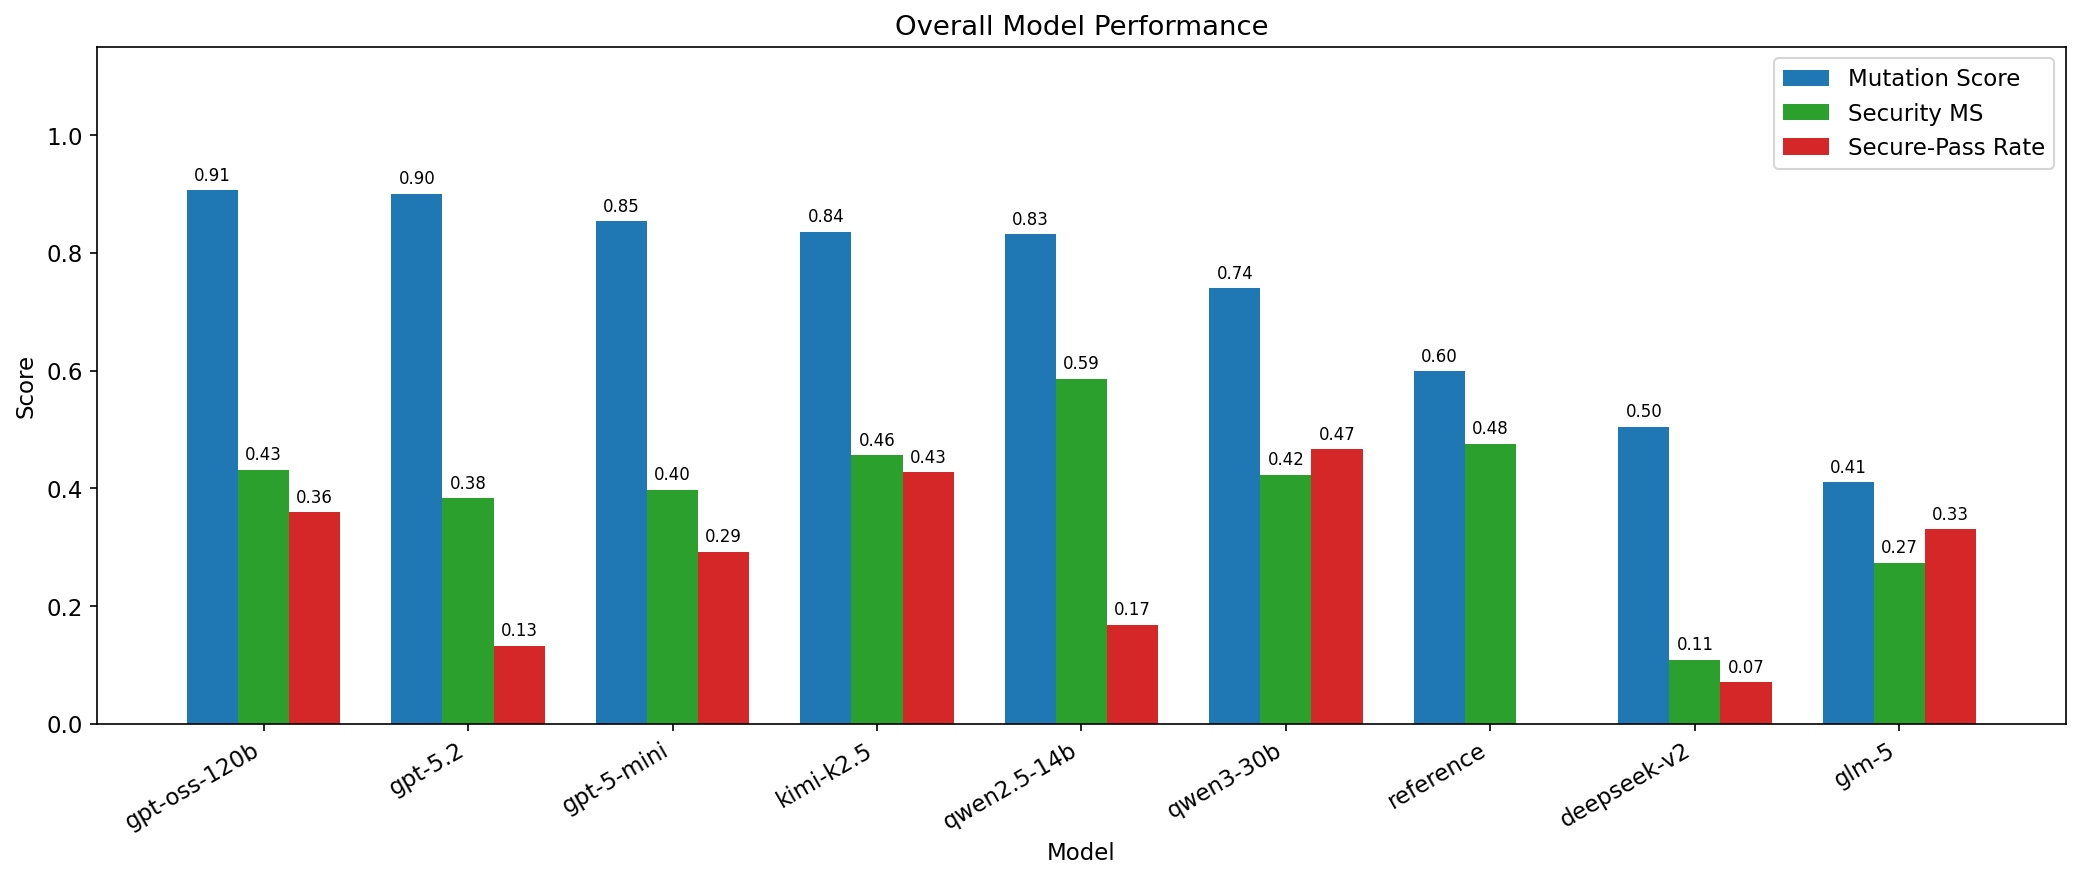

In [12]:
# Grouped bar chart: Mutation Score, Security MS, Secure-Pass Rate
plot_df = models_df.sort_values('avg_mutation_score', ascending=False).copy()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(plot_df))
width = 0.25

bars1 = ax.bar(x - width, plot_df['avg_mutation_score'], width, label='Mutation Score', color='#1f77b4')
bars2 = ax.bar(x, plot_df['avg_security_mutation_score'], width, label='Security MS', color='#2ca02c')
bars3 = ax.bar(x + width, plot_df['secure_pass_rate'], width, label='Secure-Pass Rate', color='#d62728')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Overall Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['model'], rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1.15)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Kill Type Breakdown

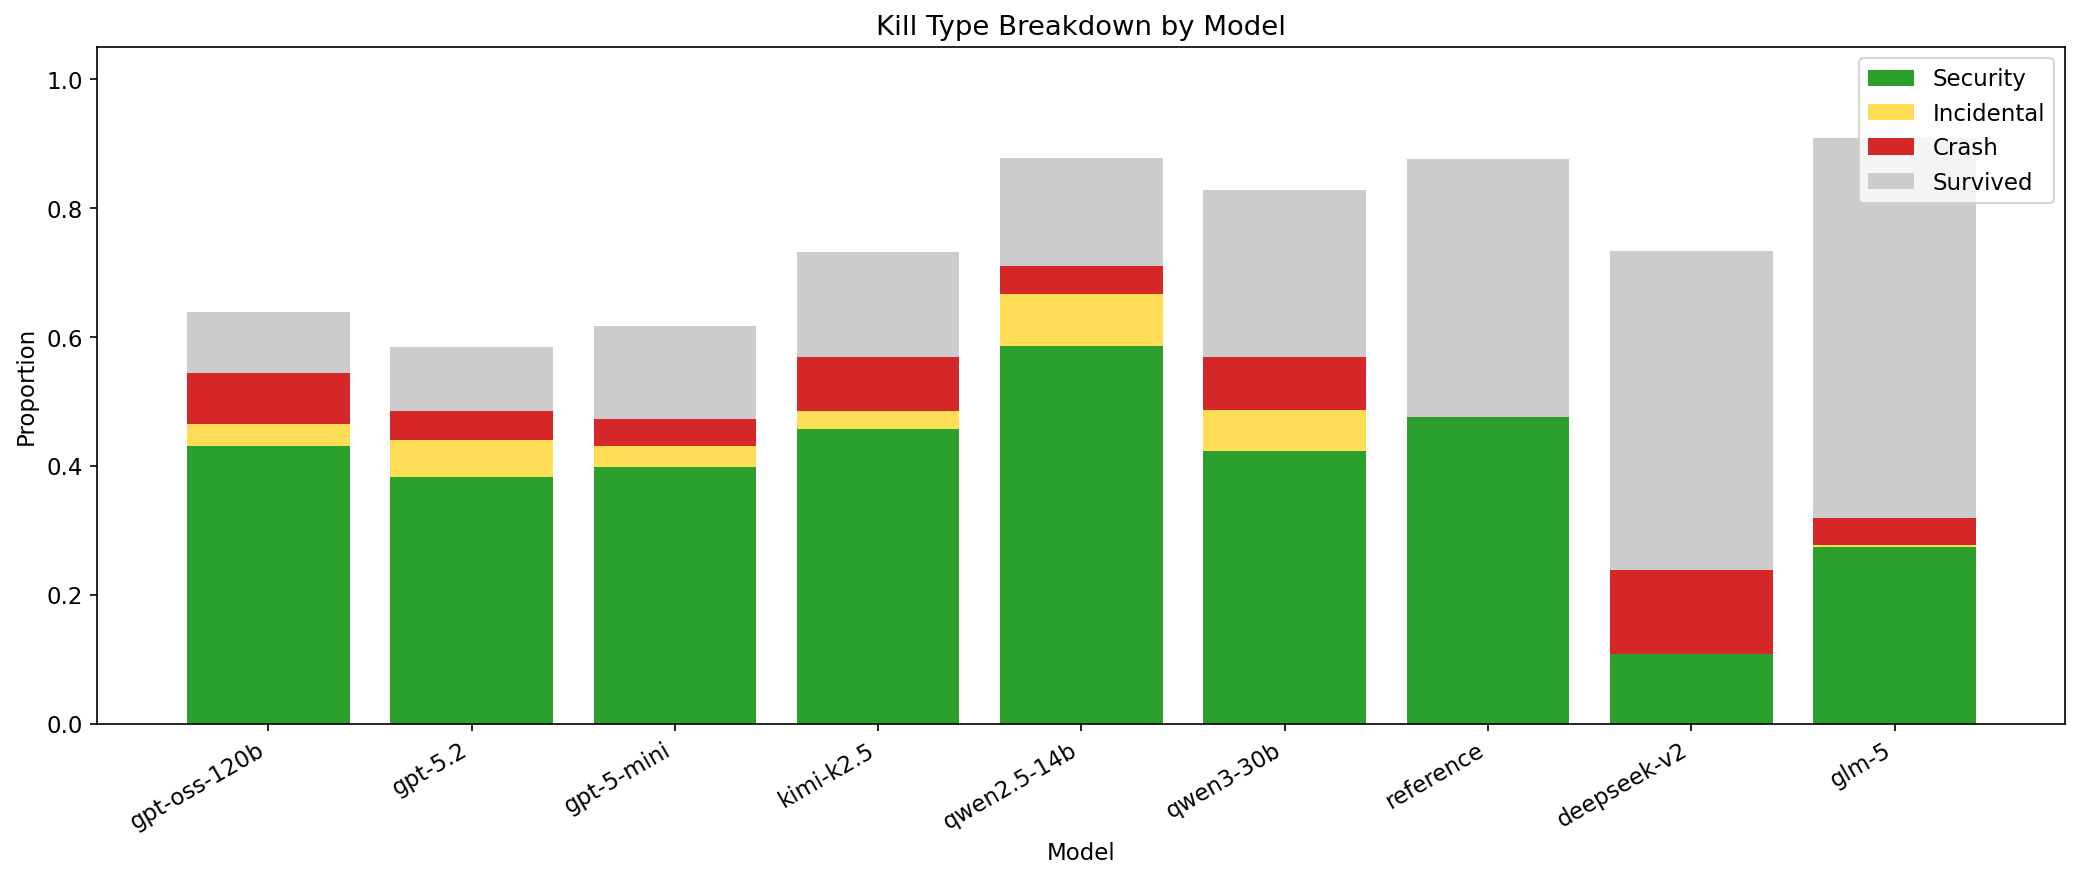

In [13]:
# Stacked bar: Security, Incidental, Crash, Survived
plot_df = models_df.sort_values('avg_mutation_score', ascending=False).copy()
plot_df['survived'] = 1.0 - plot_df['avg_mutation_score'].clip(upper=1.0)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(plot_df))

ax.bar(x, plot_df['avg_security_mutation_score'], label='Security', color='#2ca02c')
ax.bar(x, plot_df['avg_incidental_score'], bottom=plot_df['avg_security_mutation_score'],
       label='Incidental', color='#ffdd57')
bottom2 = plot_df['avg_security_mutation_score'] + plot_df['avg_incidental_score']
ax.bar(x, plot_df['avg_crash_score'], bottom=bottom2, label='Crash', color='#d62728')
bottom3 = bottom2 + plot_df['avg_crash_score']
ax.bar(x, plot_df['survived'], bottom=bottom3, label='Survived', color='#cccccc')

ax.set_xlabel('Model')
ax.set_ylabel('Proportion')
ax.set_title('Kill Type Breakdown by Model')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['model'], rotation=30, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Performance by Difficulty

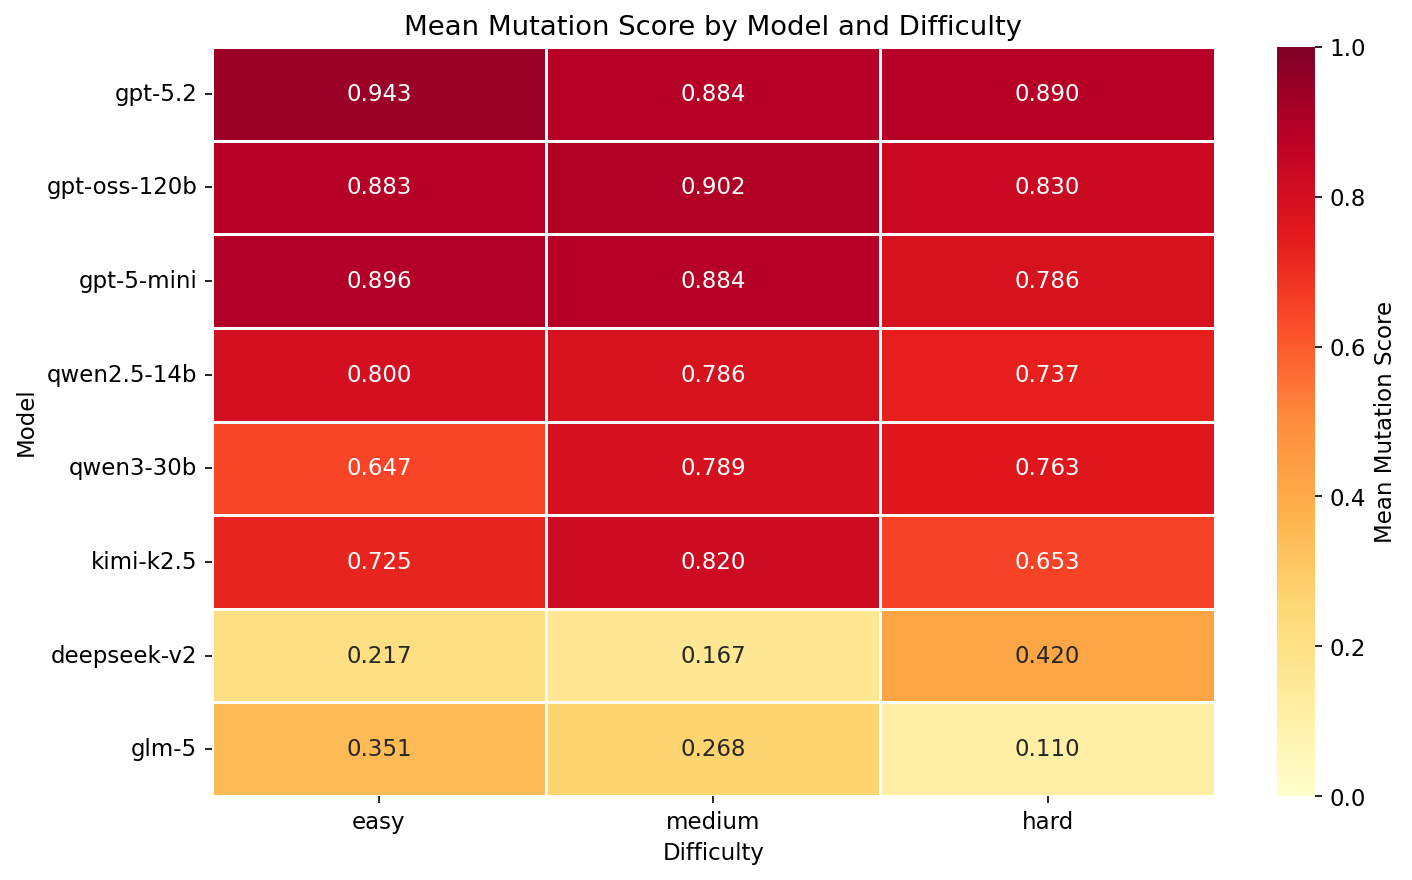

In [14]:
# Heatmap of mutation score by model x difficulty
diff_pivot = samples_df.groupby(['model', 'difficulty'])['mutation_score'].mean().unstack()
diff_pivot = diff_pivot.reindex(columns=DIFFICULTY_ORDER)
# Sort models by overall avg
diff_pivot['avg'] = diff_pivot.mean(axis=1)
diff_pivot = diff_pivot.sort_values('avg', ascending=False).drop(columns='avg')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(diff_pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Mean Mutation Score'})
ax.set_title('Mean Mutation Score by Model and Difficulty')
ax.set_ylabel('Model')
ax.set_xlabel('Difficulty')
plt.tight_layout()
plt.show()

## Mutation Score by CWE

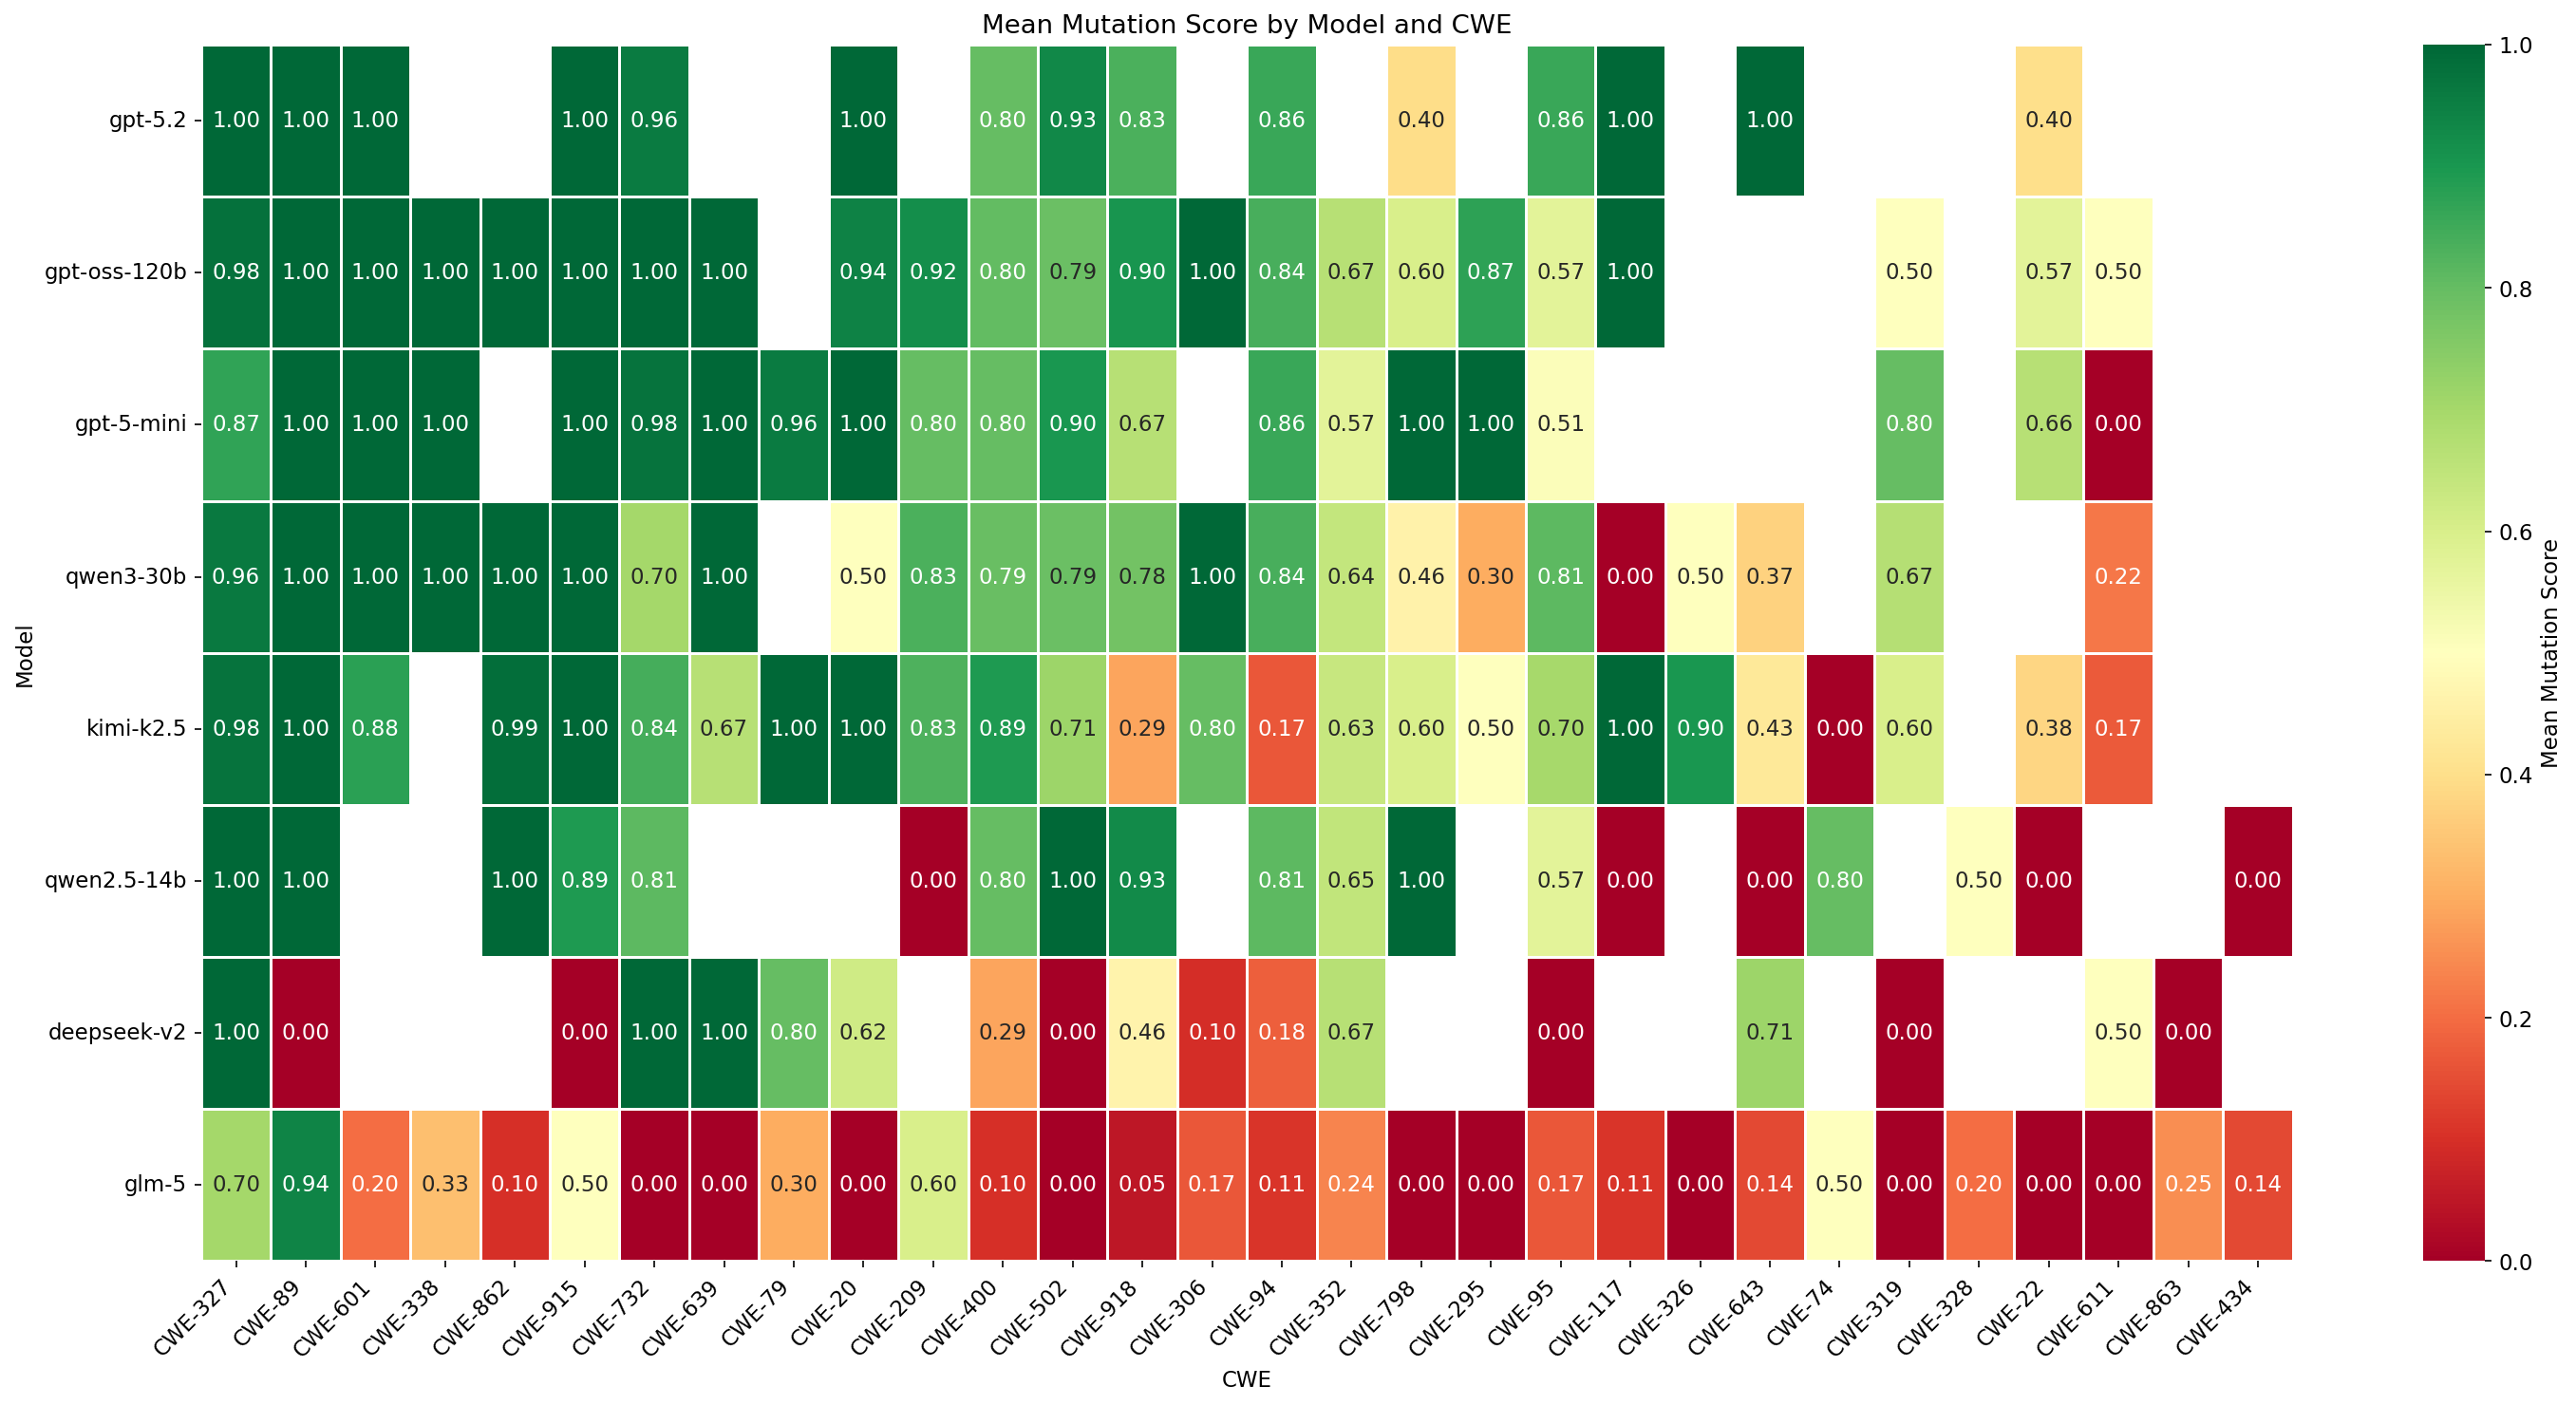

In [15]:
# Heatmap: model x CWE
cwe_pivot = samples_df.groupby(['model', 'cwe'])['mutation_score'].mean().unstack()

# Sort CWEs by average score across models
cwe_order = cwe_pivot.mean(axis=0).sort_values(ascending=False).index
cwe_pivot = cwe_pivot[cwe_order]

# Sort models by overall avg
model_order = cwe_pivot.mean(axis=1).sort_values(ascending=False).index
cwe_pivot = cwe_pivot.loc[model_order]

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(cwe_pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Mean Mutation Score'})
ax.set_title('Mean Mutation Score by Model and CWE')
ax.set_ylabel('Model')
ax.set_xlabel('CWE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Multi-Dimensional Model Comparison

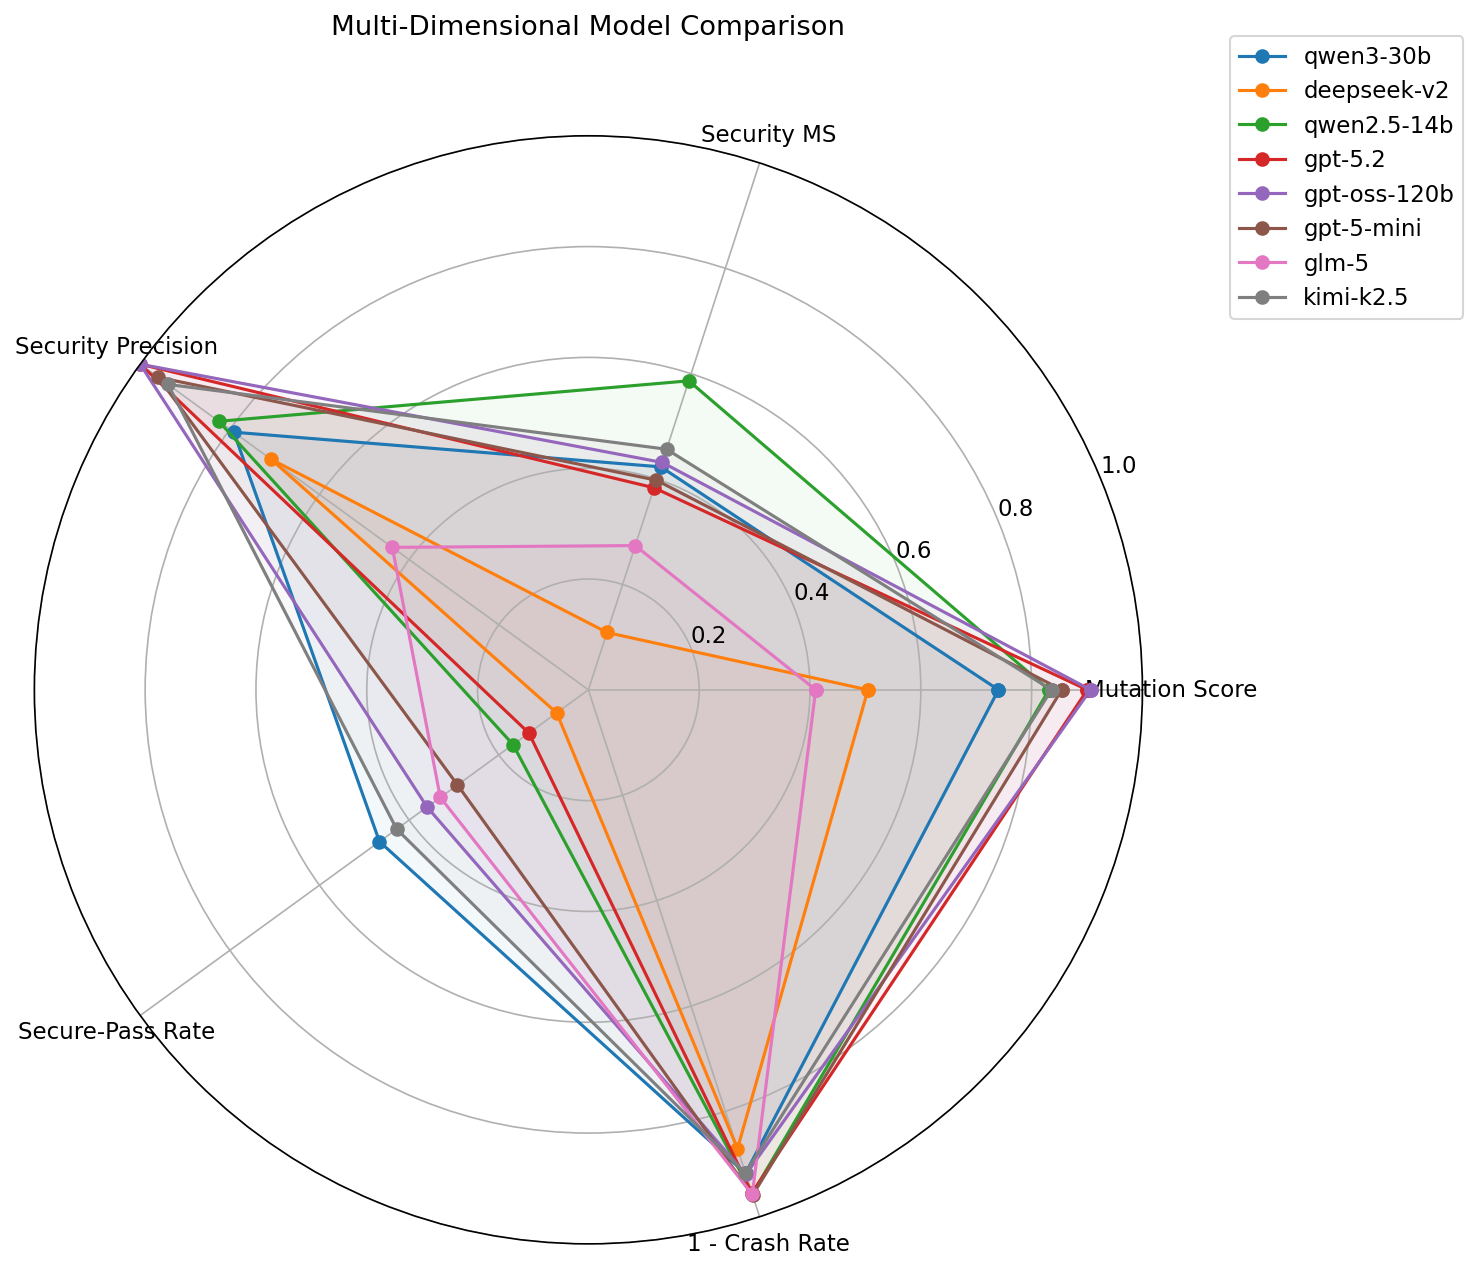

In [16]:
# Radar chart
categories = ['Mutation Score', 'Security MS', 'Security Precision', 'Secure-Pass Rate', '1 - Crash Rate']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

llm_models = models_df[models_df['model'] != 'reference']

for _, row in llm_models.iterrows():
    values = [
        row['avg_mutation_score'],
        row['avg_security_mutation_score'],
        row['avg_security_precision'],
        row['secure_pass_rate'],
        1.0 - row['avg_crash_score'],
    ]
    values += values[:1]  # close
    ax.plot(angles, values, 'o-', linewidth=1.5, label=row['model'],
            color=MODEL_COLORS.get(row['model'], '#333333'))
    ax.fill(angles, values, alpha=0.05, color=MODEL_COLORS.get(row['model'], '#333333'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Multi-Dimensional Model Comparison', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

## LLM-as-Judge: Security Scores

/var/folders/c7/tjt6kd0n5cdftvmwvkkt641m0000gn/T/ipykernel_86013/2834385035.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sec_valid, x='model', y='sec_judge_score', order=model_order_sec, ax=ax1,
/var/folders/c7/tjt6kd0n5cdftvmwvkkt641m0000gn/T/ipykernel_86013/2834385035.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
/var/folders/c7/tjt6kd0n5cdftvmwvkkt641m0000gn/T/ipykernel_86013/2834385035.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=oai_valid, x='model', y='openai_sec_score', order=model_order_oai, ax=ax2,
/

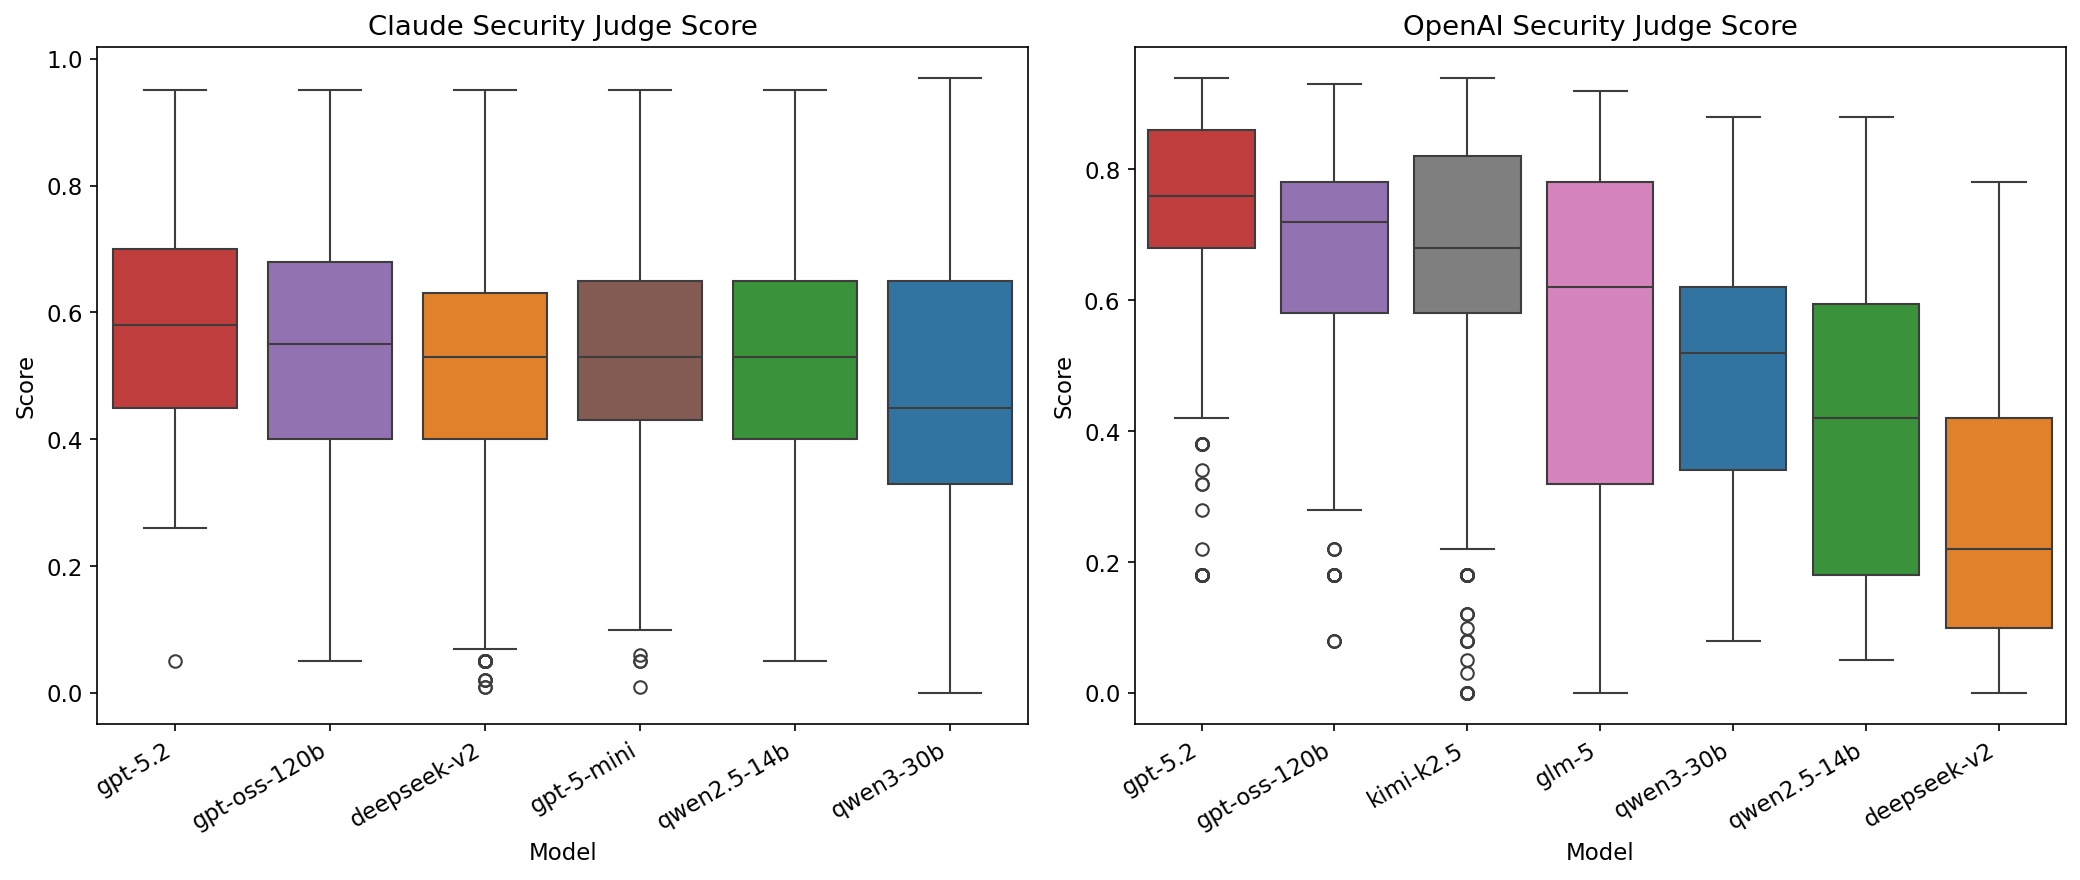

In [17]:
# Box plots for security judge scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Claude security judge
if 'sec_judge_score' in samples_df.columns:
    sec_valid = samples_df.dropna(subset=['sec_judge_score'])
    if len(sec_valid) > 0:
        model_order_sec = sec_valid.groupby('model')['sec_judge_score'].median().sort_values(ascending=False).index
        sns.boxplot(data=sec_valid, x='model', y='sec_judge_score', order=model_order_sec, ax=ax1,
                    palette=[MODEL_COLORS.get(m, '#999') for m in model_order_sec])
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
    else:
        ax1.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax1.transAxes)
else:
    ax1.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax1.transAxes)
ax1.set_title('Claude Security Judge Score')
ax1.set_ylabel('Score')
ax1.set_xlabel('Model')

# Right: OpenAI security judge
if 'openai_sec_score' in samples_df.columns:
    oai_valid = samples_df.dropna(subset=['openai_sec_score'])
    if len(oai_valid) > 0:
        model_order_oai = oai_valid.groupby('model')['openai_sec_score'].median().sort_values(ascending=False).index
        sns.boxplot(data=oai_valid, x='model', y='openai_sec_score', order=model_order_oai, ax=ax2,
                    palette=[MODEL_COLORS.get(m, '#999') for m in model_order_oai])
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')
    else:
        ax2.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax2.transAxes)
else:
    ax2.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax2.transAxes)
ax2.set_title('OpenAI Security Judge Score')
ax2.set_ylabel('Score')
ax2.set_xlabel('Model')

plt.tight_layout()
plt.show()

## LLM-as-Judge: Quality Scores

/var/folders/c7/tjt6kd0n5cdftvmwvkkt641m0000gn/T/ipykernel_86013/3443052328.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=qual_valid, x='model', y='qual_judge_score', order=model_order_q, ax=ax1,
/var/folders/c7/tjt6kd0n5cdftvmwvkkt641m0000gn/T/ipykernel_86013/3443052328.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
/var/folders/c7/tjt6kd0n5cdftvmwvkkt641m0000gn/T/ipykernel_86013/3443052328.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=oai_q_valid, x='model', y='openai_qual_score', order=model_order_oq, ax=ax2,

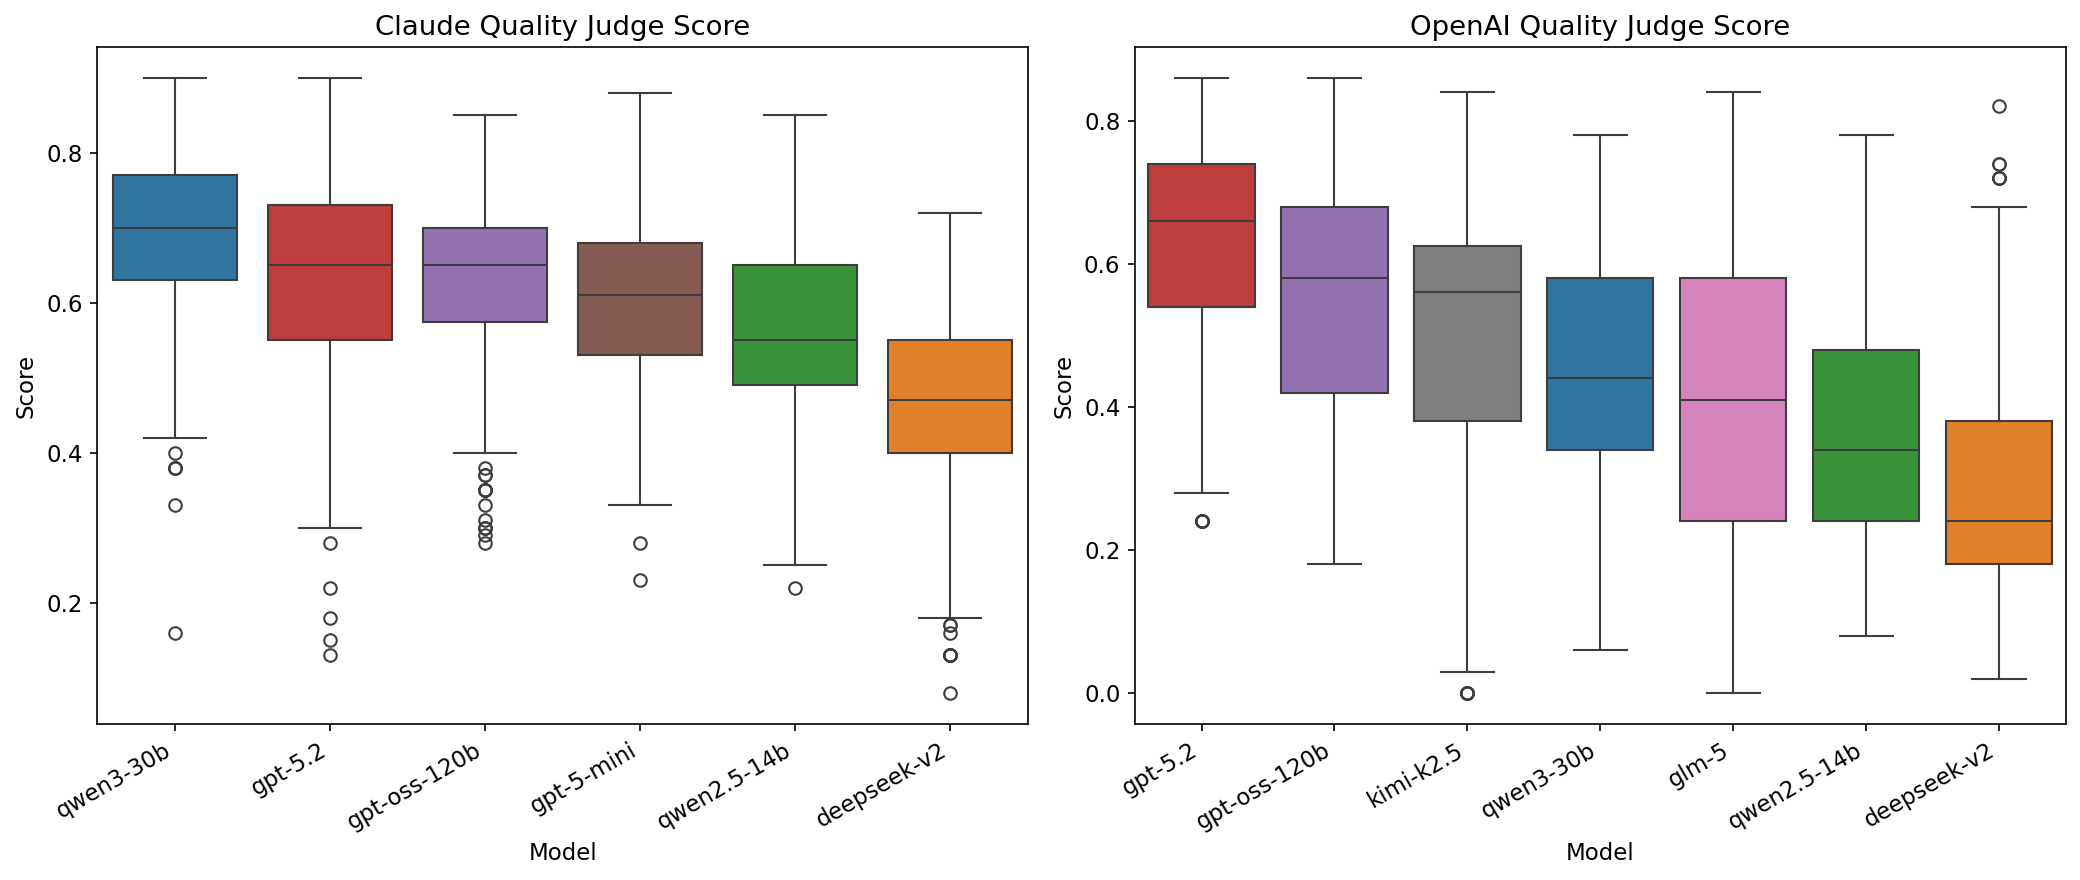

In [18]:
# Box plots for quality judge scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Claude quality judge
if 'qual_judge_score' in samples_df.columns:
    qual_valid = samples_df.dropna(subset=['qual_judge_score'])
    if len(qual_valid) > 0:
        model_order_q = qual_valid.groupby('model')['qual_judge_score'].median().sort_values(ascending=False).index
        sns.boxplot(data=qual_valid, x='model', y='qual_judge_score', order=model_order_q, ax=ax1,
                    palette=[MODEL_COLORS.get(m, '#999') for m in model_order_q])
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
    else:
        ax1.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax1.transAxes)
else:
    ax1.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax1.transAxes)
ax1.set_title('Claude Quality Judge Score')
ax1.set_ylabel('Score')
ax1.set_xlabel('Model')

# Right: OpenAI quality judge
if 'openai_qual_score' in samples_df.columns:
    oai_q_valid = samples_df.dropna(subset=['openai_qual_score'])
    if len(oai_q_valid) > 0:
        model_order_oq = oai_q_valid.groupby('model')['openai_qual_score'].median().sort_values(ascending=False).index
        sns.boxplot(data=oai_q_valid, x='model', y='openai_qual_score', order=model_order_oq, ax=ax2,
                    palette=[MODEL_COLORS.get(m, '#999') for m in model_order_oq])
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')
    else:
        ax2.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax2.transAxes)
else:
    ax2.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax2.transAxes)
ax2.set_title('OpenAI Quality Judge Score')
ax2.set_ylabel('Score')
ax2.set_xlabel('Model')

plt.tight_layout()
plt.show()

## Judge Composite Scores

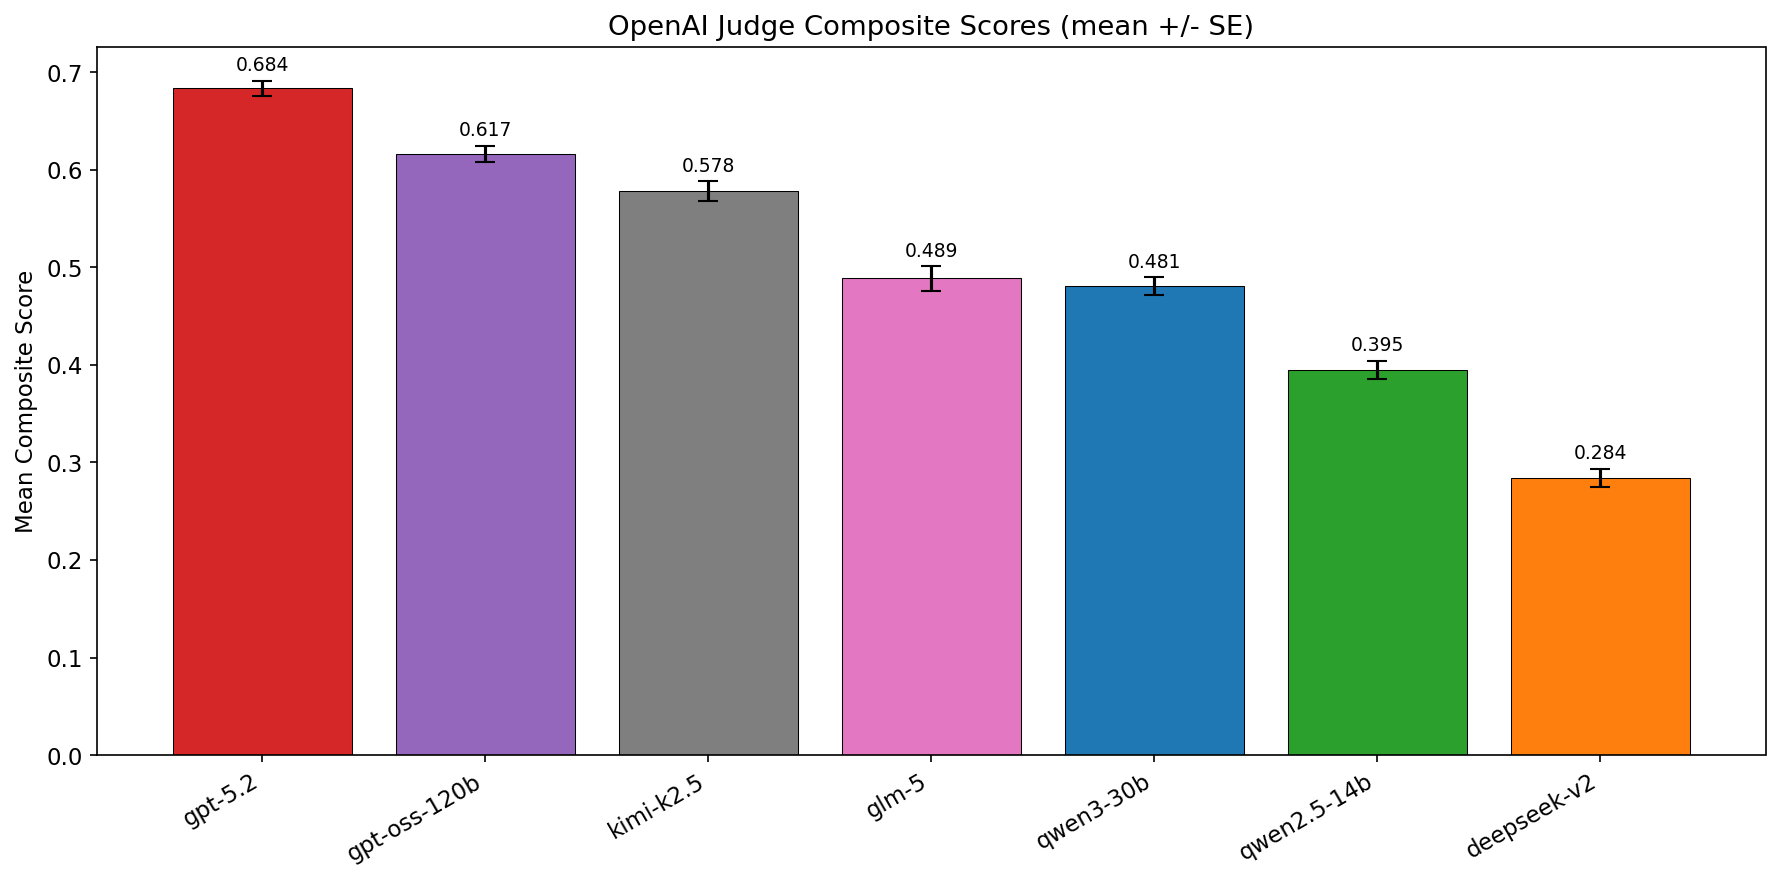

In [19]:
# Bar chart of mean openai_composite per model with std error bars
if 'openai_composite' in samples_df.columns:
    comp_stats = samples_df.dropna(subset=['openai_composite']).groupby('model')['openai_composite'].agg(['mean', 'std', 'count'])
    comp_stats['se'] = comp_stats['std'] / np.sqrt(comp_stats['count'])
    comp_stats = comp_stats.sort_values('mean', ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = [MODEL_COLORS.get(m, '#999') for m in comp_stats.index]
    ax.bar(range(len(comp_stats)), comp_stats['mean'], yerr=comp_stats['se'],
           capsize=5, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(comp_stats)))
    ax.set_xticklabels(comp_stats.index, rotation=30, ha='right')
    ax.set_ylabel('Mean Composite Score')
    ax.set_title('OpenAI Judge Composite Scores (mean +/- SE)')
    for i, (idx, row) in enumerate(comp_stats.iterrows()):
        ax.text(i, row['mean'] + row['se'] + 0.01, f'{row["mean"]:.3f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No openai_composite data available.')

## CWE Addressed Rate

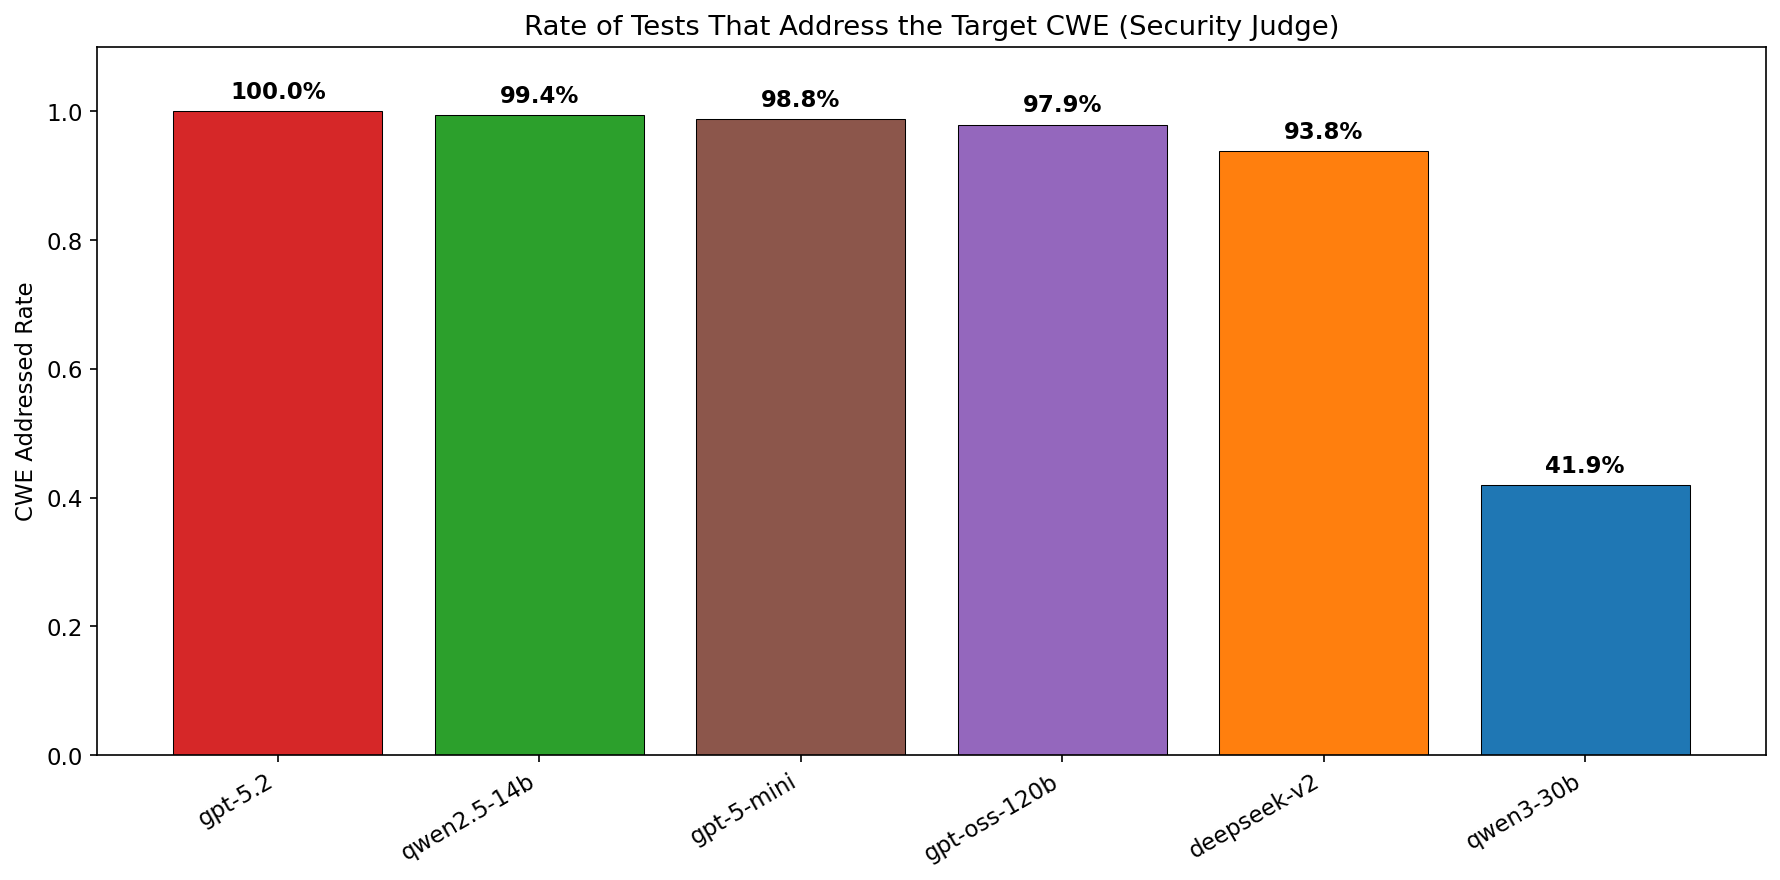

In [20]:
# For models with security judge, compute % where cwe_addressed == True
if 'cwe_addressed' in samples_df.columns:
    cwe_addr = samples_df.dropna(subset=['cwe_addressed']).copy()
    cwe_addr['cwe_addressed_bool'] = cwe_addr['cwe_addressed'].astype(bool)
    addr_rate = cwe_addr.groupby('model')['cwe_addressed_bool'].mean().sort_values(ascending=False)
    
    if len(addr_rate) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        colors = [MODEL_COLORS.get(m, '#999') for m in addr_rate.index]
        bars = ax.bar(range(len(addr_rate)), addr_rate.values, color=colors, edgecolor='black', linewidth=0.5)
        ax.set_xticks(range(len(addr_rate)))
        ax.set_xticklabels(addr_rate.index, rotation=30, ha='right')
        ax.set_ylabel('CWE Addressed Rate')
        ax.set_title('Rate of Tests That Address the Target CWE (Security Judge)')
        ax.set_ylim(0, 1.1)
        for i, v in enumerate(addr_rate.values):
            ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print('No CWE addressed data available.')
else:
    print('No cwe_addressed column in samples_df.')

## Correlation: Mutation Score vs Judge Scores

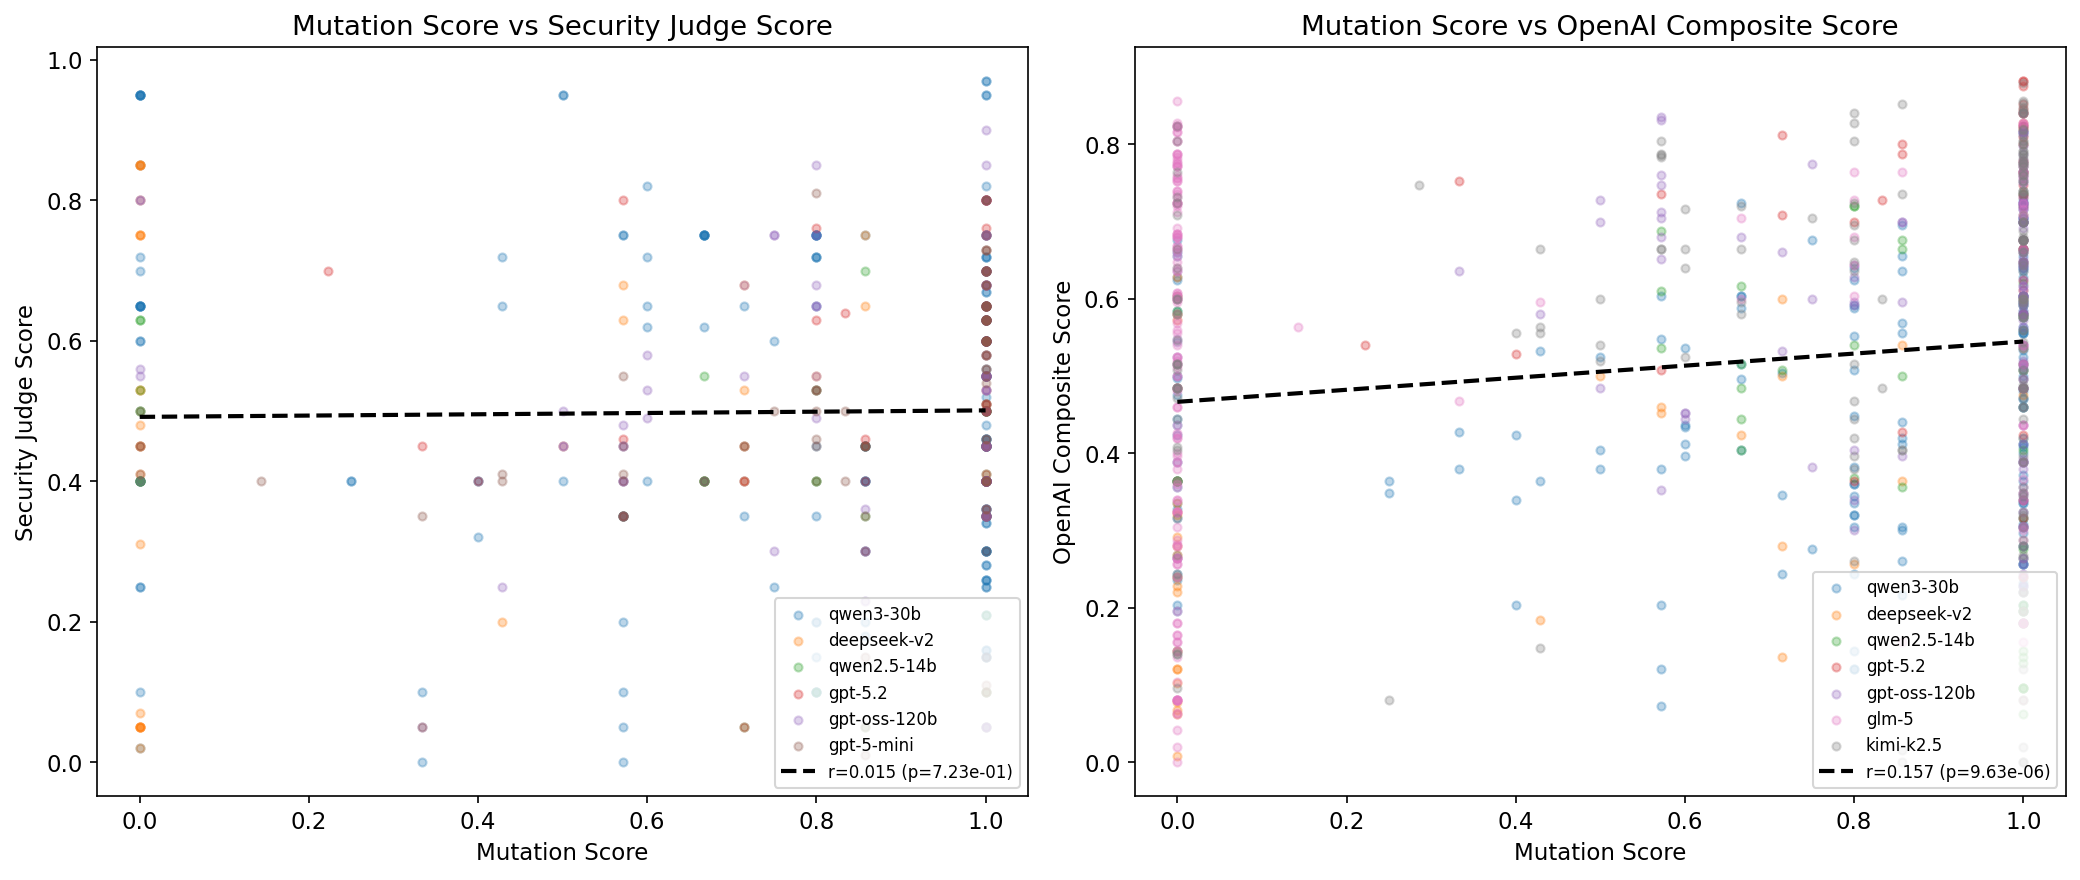

In [21]:
# Scatter plots: mutation_score vs judge scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: mutation_score vs sec_judge_score
if 'sec_judge_score' in samples_df.columns:
    plot_data = samples_df.dropna(subset=['sec_judge_score', 'mutation_score'])
    if len(plot_data) > 0:
        for model_name in plot_data['model'].unique():
            mdata = plot_data[plot_data['model'] == model_name]
            ax1.scatter(mdata['mutation_score'], mdata['sec_judge_score'], alpha=0.3, s=15,
                       color=MODEL_COLORS.get(model_name, '#999'), label=model_name)
        # Overall regression line
        from scipy import stats
        r, p = stats.pearsonr(plot_data['mutation_score'], plot_data['sec_judge_score'])
        z = np.polyfit(plot_data['mutation_score'], plot_data['sec_judge_score'], 1)
        xline = np.linspace(0, 1, 100)
        ax1.plot(xline, np.polyval(z, xline), 'k--', linewidth=2, label=f'r={r:.3f} (p={p:.2e})')
        ax1.legend(fontsize=8, loc='lower right')
    else:
        ax1.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax1.transAxes)
else:
    ax1.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax1.transAxes)
ax1.set_xlabel('Mutation Score')
ax1.set_ylabel('Security Judge Score')
ax1.set_title('Mutation Score vs Security Judge Score')

# Right: mutation_score vs openai_composite
if 'openai_composite' in samples_df.columns:
    plot_data2 = samples_df.dropna(subset=['openai_composite', 'mutation_score'])
    if len(plot_data2) > 0:
        for model_name in plot_data2['model'].unique():
            mdata = plot_data2[plot_data2['model'] == model_name]
            ax2.scatter(mdata['mutation_score'], mdata['openai_composite'], alpha=0.3, s=15,
                       color=MODEL_COLORS.get(model_name, '#999'), label=model_name)
        r2, p2 = stats.pearsonr(plot_data2['mutation_score'], plot_data2['openai_composite'])
        z2 = np.polyfit(plot_data2['mutation_score'], plot_data2['openai_composite'], 1)
        ax2.plot(xline, np.polyval(z2, xline), 'k--', linewidth=2, label=f'r={r2:.3f} (p={p2:.2e})')
        ax2.legend(fontsize=8, loc='lower right')
    else:
        ax2.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax2.transAxes)
else:
    ax2.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax2.transAxes)
ax2.set_xlabel('Mutation Score')
ax2.set_ylabel('OpenAI Composite Score')
ax2.set_title('Mutation Score vs OpenAI Composite Score')

plt.tight_layout()
plt.show()

## Summary Table

In [22]:
# Display models_df with all metrics, styled
summary = models_df.drop_duplicates(subset='model').sort_values('avg_mutation_score', ascending=False).copy()
summary = summary.set_index('model')

# Add judge mean scores
for col, new_col in [('sec_judge_score', 'mean_sec_judge'), ('qual_judge_score', 'mean_qual_judge'),
                      ('openai_composite', 'mean_oai_composite')]:
    if col in samples_df.columns:
        judge_means = samples_df.groupby('model')[col].mean()
        summary[new_col] = summary.index.map(judge_means)

numeric_cols = summary.select_dtypes(include=[np.number]).columns.tolist()

styled = summary.style.background_gradient(cmap='YlGn', subset=numeric_cols).format(
    {c: '{:.3f}' for c in numeric_cols if c != 'samples'}
).format({'samples': '{:.0f}'})

display(styled)

,samples,avg_mutation_score,avg_security_mutation_score,avg_incidental_score,avg_crash_score,avg_security_precision,secure_pass_rate,mean_sec_judge,mean_qual_judge,mean_oai_composite
model,,,,,,,,,,
gpt-oss-120b,339,0.906382,0.431548,0.032738,0.080357,1.000000,0.359882,0.545959,0.634366,0.616537
gpt-5.2,339,0.900705,0.383459,0.056391,0.045113,1.000000,0.132743,0.583127,0.634012,0.683522
gpt-5-mini,339,0.854329,0.397770,0.033457,0.040892,0.959596,0.292035,0.537286,0.602006,nan
kimi-k2.5,339,0.835895,0.456604,0.028931,0.083019,0.937931,0.427729,nan,nan,0.578106
qwen2.5-14b,339,0.831412,0.586420,0.080247,0.043210,0.824561,0.168142,0.506726,0.560059,0.394802
qwen3-30b,339,0.740175,0.423123,0.063170,0.082241,0.791139,0.466077,0.481386,0.695133,0.480950
reference,339,0.599185,0.475655,0.000000,0.000000,0.000000,0.000000,nan,nan,nan
deepseek-v2,339,0.504563,0.108844,0.000000,0.129252,0.708333,0.070796,0.489971,0.458820,0.284372
glm-5,339,0.410289,0.273770,0.003279,0.042623,0.437500,0.330383,nan,nan,0.488596


## Performance by Source Type

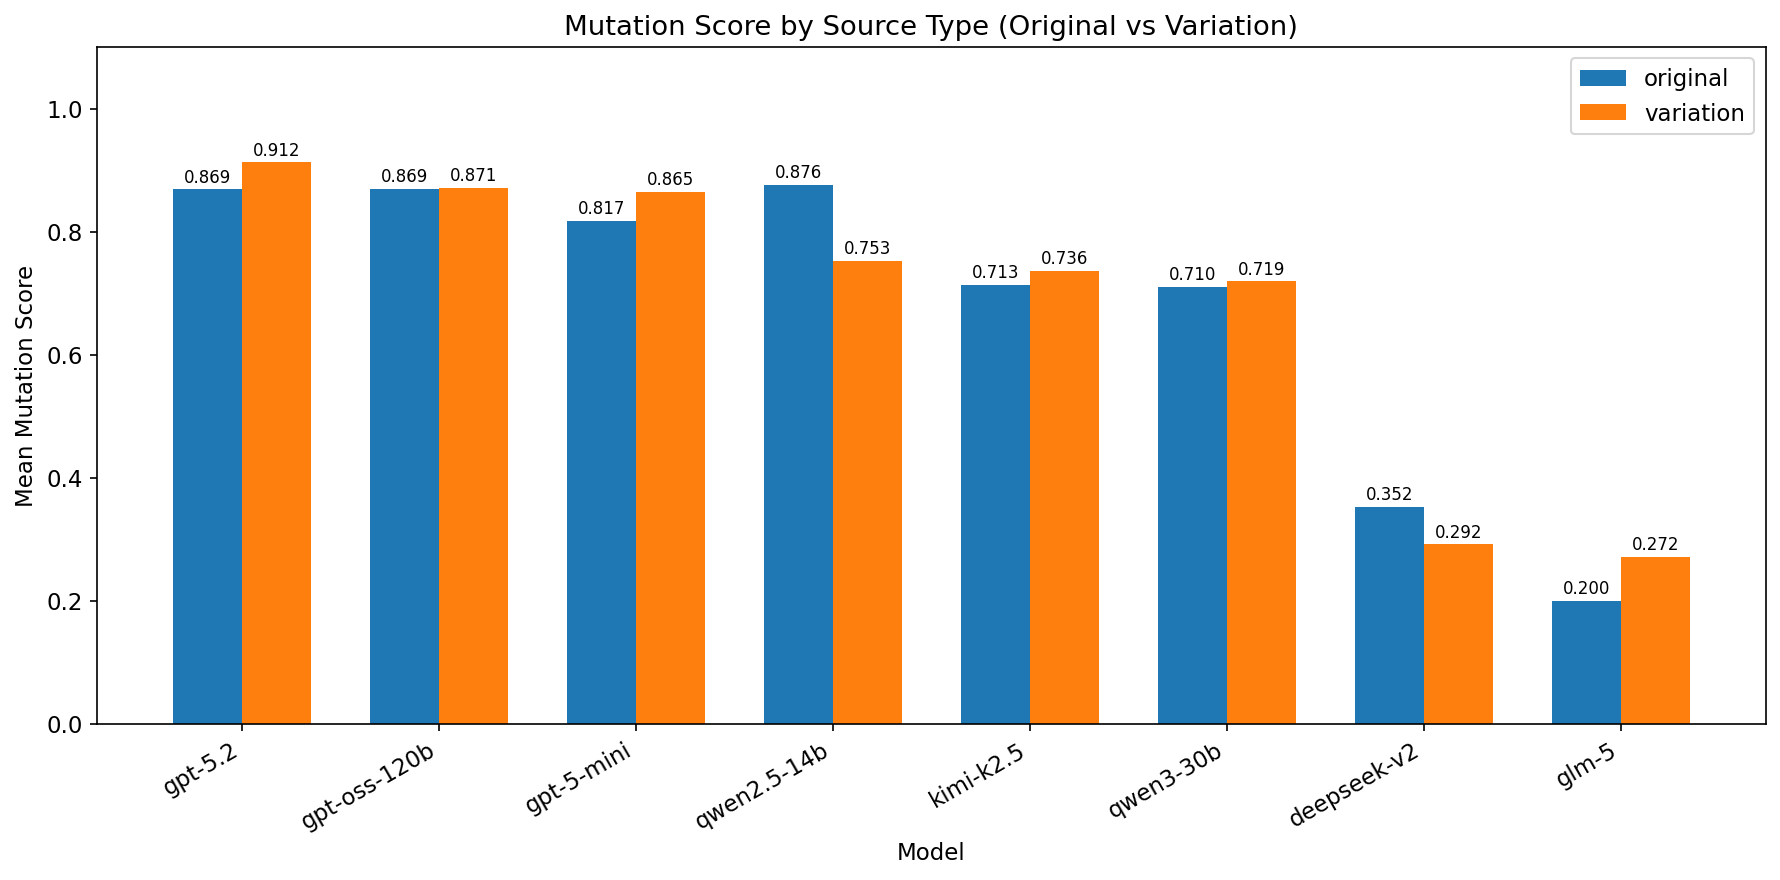

In [23]:
# Grouped bar: x=model, bars for original vs variation mean mutation_score
src_pivot = samples_df.groupby(['model', 'source_type'])['mutation_score'].mean().unstack(fill_value=0)

# Sort by overall avg
src_pivot['avg'] = src_pivot.mean(axis=1)
src_pivot = src_pivot.sort_values('avg', ascending=False).drop(columns='avg')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(src_pivot))
width = 0.35

src_cols = [c for c in ['original', 'variation'] if c in src_pivot.columns]
src_colors = {'original': '#1f77b4', 'variation': '#ff7f0e'}

for i, col in enumerate(src_cols):
    offset = (i - len(src_cols)/2 + 0.5) * width
    bars = ax.bar(x + offset, src_pivot[col], width, label=col, color=src_colors.get(col, '#999'))
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model')
ax.set_ylabel('Mean Mutation Score')
ax.set_title('Mutation Score by Source Type (Original vs Variation)')
ax.set_xticks(x)
ax.set_xticklabels(src_pivot.index, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()